# Project: Comparing Chicago and New Orleans 311 Data

## Student Name
Syeda Mah Noor Asad

## Webpage
https://syedamahnoorasad.github.io/Investigating-Nola-311-Data/

## Introduction: The Pulse of the City

311 service request systems serve as a critical pulse of a city. These systems, designed to handle non-emergency municipal issues like potholes, streetlights, and sanitation, act as a direct proxy for resident needs and government responsiveness.

For this project, I chose to conduct a comparative analysis of two vastly different urban environments: New Orleans and Chicago. New Orleans offers a unique, environmentally volatile context that hits close to home, while Chicago provides a massive, hallmark 311 system with a staggering volume of data. By analyzing their service request data from 2020 through 2025 (encompassing over 7.1 million requests in Chicago and 566,000 in New Orleans), we can explore how scale, environment, and infrastructure shape the lived experience of a city's residents.

## Dataset Source
New Orleans: https://data.nola.gov/City-Administration/311-OPCD-Calls-2012-Present-/2jgv-pqrq/data_preview
Chicago: https://catalog.data.gov/dataset/311-service-requests. 

I downloaded the data in CSV format which I later import into a dataframe using pandas.

## Goal

My goal is to perform statistical hypothesis testing and predictive modeling to forecast civic responsiveness in few different ways below:

1. Statistical Hypotheses

- Hypotheses 1: The composition of request reasons meaningfully relates to the time of year, demonstrating distinct operational shifts during specific seasons or extreme weather events.

- Hypotheses 2: Months with heavier 311 request volume inherently lead to higher average closure times.

2. Predictive Modeling

- 5.1. Can we accurately predict and explain the variance in the resolution time (closure time) of a given service request using category, temporal and geographical data?


## Path to the Goal

Before reaching the goal I will study how request volume, category mix, data completeness, and service performance differ across two urban contexts. I think this exploration of the dataset is essential before jumping into statistical testing and modelling. 

The analysis will start with cleaning and standardizing the records, then using exploratory analysis to understand what residents report, when they report it, and how quickly those requests are resolved. Finally, we will culminate our discussion in statistical hypothesis testing and predictive modeling to forecast civic responsiveness.

Some of the things I wish to learn in my exploration are: 

#### 1. Dataset Quality and Comparability

This exploration will help me get the feel of the data and understand what we are dealing. It will help me point out any glaring issues in data quality and fix before we jump into formal analysis. 

- 1.1. How large are the two datasets, and how do they compare once population size is taken into account?

- 1.2. How complete are key fields such as location, agency, request status, and closure date in each city?

- 1.3. What proportion of requests are fulfilled and unfilled across the cities?

- 1.4. What are the top 10 requests un each city?

#### 2. Temporal and Request Pattern Analysis

This should help with Hypothesis 1 and Predicvtive Modelling as I will get to see if establishing a relationship like this is even worthwhile. While it won't confirm things, it will help me form a guesstimate as to what to expect. I would feel more educated learning these things before jumping into the analysis.

- 2.1. How does 311 request activity change across months, years, and days of the week in New Orleans and Chicago?

- 2.2. Are seasonal peaks or major events, such as summer surges or hurricanes, visible in the request volume data?

- 2.3. What are the most common request categories in each city, and what do those differences suggest about local civic concerns?

#### 3. Service Performance and Spatial Equity 

I want to see these factors to form a potential idea on what I can expect for Hypothesis 2. 

- 3.1. How long do requests take to close in each city, and how is that time distributed across records?

- 3.2. Do some New Orleans council districts or Chicago precincts appear to resolve requests more efficiently than others?

- 3.3. Which request categories have the highest median and mean resolution times, and what might that imply about priority and service burden?

## Preprocessing

### Import the datasets: New Orleans and Chicago

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# Load the datasets

nola_311 = pd.read_csv('311_OPCD_Calls_2012-Present.csv')
chi_311 = pd.read_csv('chi_311.csv')




/var/folders/r0/6m_3dcrs53qf0lfygy7ffmwm0000gn/T/ipykernel_14450/210273950.py:11: DtypeWarning: Columns (14,21) have mixed types. Specify dtype option on import or set low_memory=False.
  chi_311 = pd.read_csv('chi_311.csv')


### Examining the Columns in the data

In [29]:
nola_311.head()

,Service Request #,Request Type,Request Reason,Date Created,Date Modified,Date Closed,Request Status,Responsible Agency,Address,Council District,Status,Contractor,Contractor Action,RowID,X,Y,Longitude,Latitude,Location
0,2021-847416,Mayor's Request,Requests to the Mayor,12/10/2021 09:22:27 PM,07/08/2022 02:30:48 PM,07/08/2022 09:30:48 AM,Closed,Executive Office of the Mayor,NaN,NaN,Resolved,NaN,NaN,"847,416",NaN,NaN,0.000000,0.000000,"(0.0, 0.0)"
1,2022-858955,Tax and Revenue,Occupational License Tax,02/04/2022 03:39:45 PM,02/22/2022 07:09:55 AM,02/22/2022 01:09:55 AM,Closed,Bureau of Revenue,NaN,NaN,Resolved,NaN,NaN,"858,955",NaN,NaN,0.000000,0.000000,"(0.0, 0.0)"
2,2024-1145120,Traffic Safety,Request for Traffic Calming due to Speeding,10/30/2024 12:18:29 PM,12/22/2024 04:52:36 PM,NaN,Pending,Department of Public Works,1 Bamboo Rd,A,Pending,NaN,NaN,"1,145,120","3,663,515.88941","539,789.54625",-90.124582,29.978768,"(29.978768001649772, -90.12458247242685)"
3,2024-1145799,Trash/Recycling,Missed Trash Pick-Up,11/02/2024 07:58:56 AM,12/22/2024 04:51:17 PM,11/02/2024 04:09:40 AM,Closed,Department of Sanitation,2608 Magnolia St,B,Invalid Request,IV Waste,Invalid Request,"1,145,799","3,674,205.35803","526,080.457854",-90.091290,29.940758,"(29.940758205316882, -90.091290391251)"
4,2024-1145838,Roads and Streets,Push-up/Pavement Expansion,11/02/2024 03:10:10 PM,12/22/2024 04:48:43 PM,NaN,Pending,Department of Public Works,725 Voisin St,A,Pending,NaN,NaN,"1,145,838","3,668,424.02055","543,287.21947",-90.108963,29.988242,"(29.988242136809447, -90.10896265604138)"


In [30]:
chi_311.head()

,SR_NUMBER,SR_TYPE,SR_SHORT_CODE,CREATED_DEPARTMENT,OWNER_DEPARTMENT,STATUS,ORIGIN,CREATED_DATE,LAST_MODIFIED_DATE,CLOSED_DATE,...,PRECINCT,SANITATION_DIVISION_DAYS,CREATED_HOUR,CREATED_DAY_OF_WEEK,CREATED_MONTH,X_COORDINATE,Y_COORDINATE,LATITUDE,LONGITUDE,LOCATION
0,SR21-00132297,Garbage Cart Maintenance,SIE,NaN,Streets and Sanitation,Completed,Internet,2021-01-24 21:14:58,04/15/2021 07:22:22 AM,04/15/2021 07:22:22 AM,...,15.0,NaN,21,1,1,1.155443e+06,1.868087e+06,41.793836,-87.705544,"(41.79383579077592, -87.70554390959582)"
1,SR21-00265005,Recycling Pick Up,SRRP,NaN,Streets and Sanitation,Completed,Internet,2021-02-16 20:28:59,03/06/2021 09:46:18 AM,03/06/2021 09:46:18 AM,...,39.0,NaN,20,3,2,1.158084e+06,1.900899e+06,41.883824,-87.694966,"(41.88382404700037, -87.69496586240024)"
2,SR21-00857385,Garbage Cart Maintenance,SIE,NaN,Streets and Sanitation,Completed,Internet,2021-05-21 13:27:26,06/28/2021 09:15:43 AM,06/28/2021 09:15:43 AM,...,40.0,NaN,13,6,5,1.165578e+06,1.854515e+06,41.756385,-87.668763,"(41.75638479819737, -87.66876330253068)"
3,SR20-04407621,Traffic Signal Out Complaint,SFB,311 City Services,CDOT - Department of Transportation,Canceled,Phone Call,2020-06-22 16:32:39,06/22/2020 04:35:28 PM,06/22/2020 04:35:28 PM,...,2.0,NaN,16,2,6,1.162045e+06,1.841573e+06,41.720945,-87.682070,"(41.72094524289129, -87.68207046358089)"
4,SR22-01315113,Garbage Cart Maintenance,SIE,NaN,Streets and Sanitation,Completed,Internet,2022-07-26 17:48:02,09/27/2022 09:40:19 AM,09/27/2022 09:40:19 AM,...,18.0,NaN,17,3,7,1.139717e+06,1.905056e+06,41.895585,-87.762308,"(41.89558499575442, -87.76230794313283)"


### Tidying the Datasets

### Renaming the columns in both datasets to match 

In [33]:
### Fixing column names 

### stripped leading and white space, converted to lowercase, replaced spaces with underscores
nola_311.columns = nola_311.columns.str.strip().str.lower().str.replace(' ', '_')
nola_311.rename(columns={'service_request_#': 'request_number'}, inplace=True)
nola_311.rename(columns={'rowid': 'row_id'}, inplace=True)

### rename Chicago columns to match equivalent New Orleans columns
chi_to_nola_column_map = {
    'SR_NUMBER': 'request_number',
    'SR_TYPE': 'request_reason',
    'CREATED_DATE': 'date_created',
    'LAST_MODIFIED_DATE': 'date_modified',
    'CLOSED_DATE': 'date_closed',
    'STATUS': 'request_status',
    'OWNER_DEPARTMENT': 'responsible_agency',
    'STREET_ADDRESS': 'address',
    'LONGITUDE': 'longitude',
    'LATITUDE': 'latitude',
    'ORIGIN': 'origin',
    "PRECINCT": "precinct"
}

# Keep non-equivalent Chicago columns unchanged.
chi_311 = chi_311.rename(columns=chi_to_nola_column_map)


### Drop columns not useful to me

In [34]:
### dropping redundant columns for New Orleans dataset
nola_311.drop(columns=['location'], inplace=True)



#### keep only relevantcolumns that are in both datasets except precinct and origin in Chicago dataset
keep_columns = ['request_number', 'request_reason', 'origin', 'date_created', 'date_modified', 'date_closed', 'request_status', 'responsible_agency', 'address', 'longitude', 'latitude', "precinct"]
chi_311 = chi_311[keep_columns]


### Convert columns to appropriate datatypes and Standardize Request Status

In [ ]:
### convert columns to appropriate data types
nola_311['request_number'] = nola_311['request_number'].astype(str)
nola_311['x'] = nola_311['x'].str.replace(',', '').astype(float)
nola_311['y'] = nola_311['y'].str.replace(',', '').astype(float)
nola_311['date_modified'] = pd.to_datetime(nola_311['date_modified'])
nola_311['date_created'] = pd.to_datetime(nola_311['date_created'])
nola_311['date_closed'] = pd.to_datetime(nola_311['date_closed'])

print("New Orleans 311 Data Types:")
for x in nola_311.items():
    print(x[0],",", x[1].dtype)

### convert Chicago columns to appropriate data types
string_columns = [
    'request_number', 'request_reason', 'request_status',
    'responsible_agency', 'origin', 'address', 'precinct'
]
for col in string_columns:
    chi_311[col] = chi_311[col].astype('string')
chi_311['date_created'] = pd.to_datetime(chi_311['date_created'], errors='coerce')
chi_311['date_modified'] = pd.to_datetime(chi_311['date_modified'], errors='coerce')
chi_311['date_closed'] = pd.to_datetime(chi_311['date_closed'], errors='coerce')
numeric_columns = [
    'latitude', 'longitude'
]
for col in numeric_columns:
    chi_311[col] = pd.to_numeric(chi_311[col], errors='coerce')


### standardize request_status values by replacing 'Closed' with 'Completed' and converting to string data type
chi_311['request_status'] = chi_311['request_status'].replace({'Closed': 'Completed'}).astype('string')

print("Chicago 311 Data Types:")
for x in chi_311.items():
    print(x[0],",", x[1].dtype)

New Orleans 311 Data Types:
request_number , object
request_type , object
request_reason , object
date_created , datetime64[ns]
date_modified , datetime64[ns]
date_closed , datetime64[ns]
request_status , object
responsible_agency , object
address , object
council_district , object
status , object
contractor , object
contractor_action , object
row_id , object
x , float64
y , float64
longitude , float64
latitude , float64
Chicago 311 Data Types:
request_number , string
request_reason , string
origin , string
date_created , datetime64[ns]
date_modified , datetime64[ns]
date_closed , datetime64[ns]
request_status , string
responsible_agency , string
address , string
longitude , float64
latitude , float64
precinct , string


### Ensure data is between 2020-2025

In [41]:
### subset New Orleans data from January 1, 2020 through December 31, 2025
nola_start_date = pd.Timestamp('2020-01-01' + ' 00:00:00')
nola_end_date = pd.Timestamp('2025-12-31 23:59:59')
nola_311 = nola_311[
    nola_311['date_created'].between(nola_start_date, nola_end_date)
].copy()
nola_311.head()
print(f"New Orleans 311 data start date: {nola_311['date_created'].min()}")
print(f"New Orleans 311 data end date: {nola_311['date_created'].max()}")


### chicago data start and end dates
chi_start_date = chi_311['date_created'].min()
chi_end_date = chi_311['date_created'].max()
print(f"Chicago 311 data start date: {chi_start_date}")
print(f"Chicago 311 data end date: {chi_end_date}")





New Orleans 311 data start date: 2020-01-01 09:15:44
New Orleans 311 data end date: 2025-12-31 23:24:52
Chicago 311 data start date: 2020-01-01 00:08:11
Chicago 311 data end date: 2025-12-31 23:59:32


### Let's remove "information only" requests from the datasets

In [42]:
## remove information only requests 
chi_311 = chi_311[~chi_311['request_reason'].str.contains('311 INFORMATION ONLY CALL', case=False, na=False)].copy()

### Dataset size after preprocessing 

In [43]:
print("Datapoints in New Orleans dataset:", len(nola_311))
print("Datapoints in Chicago dataset:", len(chi_311))

Datapoints in New Orleans dataset: 566555
Datapoints in Chicago dataset: 7125138


## Path to Goal

### 1. Dataset Quality and Comparability

### 1.1. How large are the two datasets?

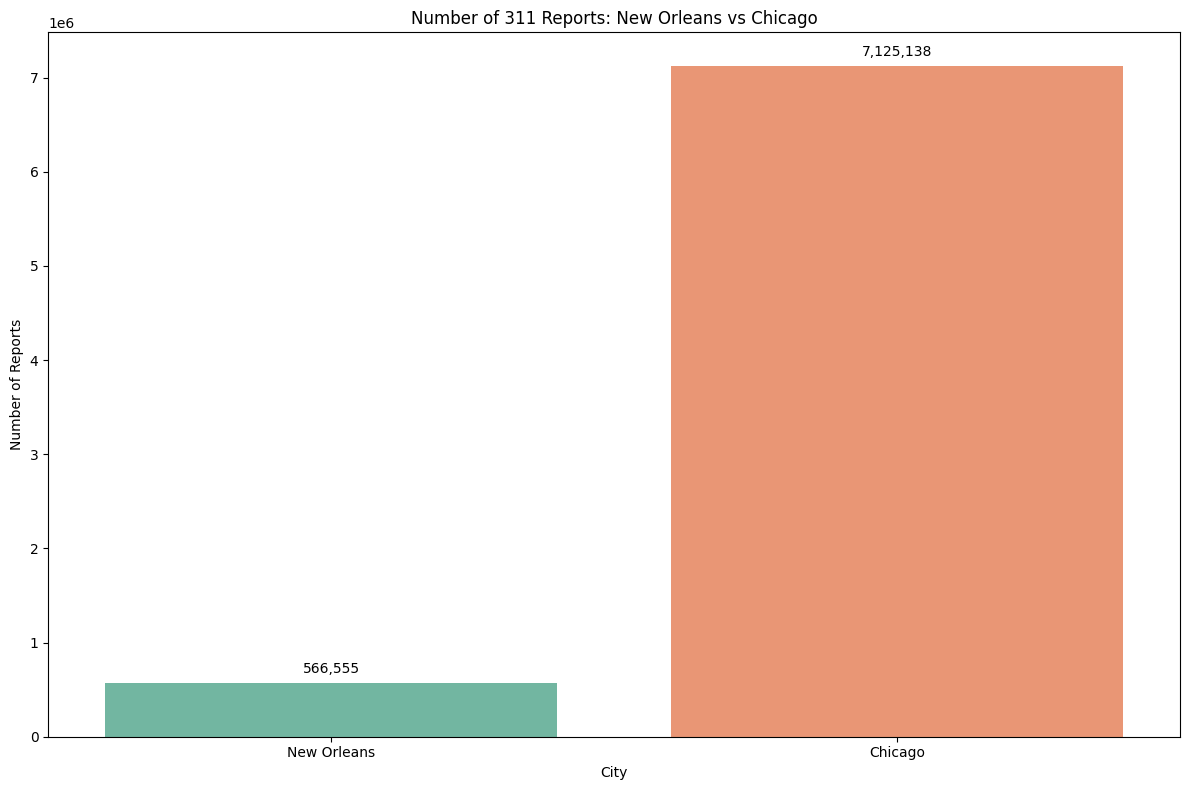

In [44]:
report_counts = pd.DataFrame({
    'city': ['New Orleans', 'Chicago'],
    'report_count': [len(nola_311), len(chi_311)]
})

plt.figure(figsize=(12, 8))
ax = sns.barplot(data=report_counts, x='city', y='report_count', hue='city', palette='Set2', legend=False)

for bar in ax.patches:
    height = int(bar.get_height())
    ax.annotate(f'{height:,}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.title('Number of 311 Reports: New Orleans vs Chicago')
plt.xlabel('City')
plt.ylabel('Number of Reports')
plt.tight_layout()
plt.show()


The chicago data is about 28x larger than that of New Orleans for 2020-2025. 

The population of New Orleans was 384,139 and that of Chicago was 2,748,331 as of April 2024 [[1](https://www.census.gov/quickfacts/fact/table/neworleanscitylouisiana/PST040224#PST040224)],[[2](https://www.census.gov/quickfacts/fact/table/chicagocityillinois/PST045224)]. The population of Chicago is only 7x that of New Orleans.

How do the datasets compare once population size is taken into account? Let's plot into a bar graph.

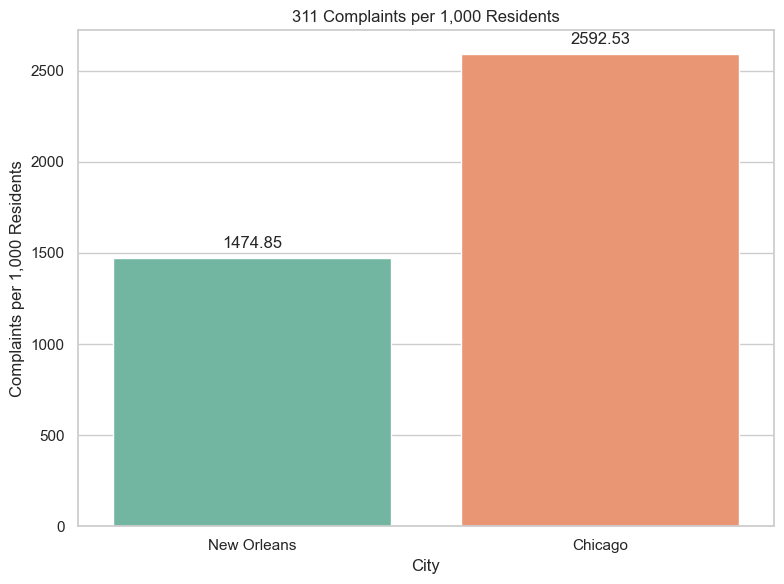

In [34]:
nola_pop = 384130 ### april 2024
chi_pop = 2748331 ### april 2024


### average number of complaints per 1000 residents  
complaints_per_1000 = pd.DataFrame({
    'city': ['New Orleans', 'Chicago'],
    'complaints_per_1000': [
        len(nola_311) / nola_pop * 1000,
        len(chi_311) / chi_pop * 1000
    ]
})

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=complaints_per_1000, x='city', y='complaints_per_1000', hue='city', palette='Set2', legend=False)

for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                (bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.title('311 Complaints per 1,000 Residents')
plt.xlabel('City')
plt.ylabel('Complaints per 1,000 Residents')
plt.tight_layout()
plt.show()


There is a significant difference between average number of requests per citizens. Chicago leads by 4 requests per person while New Orleans gets 1 request per citizen on average in a duration of 5 years. 

#### 1.2. Data Completeness

How complete are key fields in both the datasets? Lets use a heatmap for easy visual comparison!


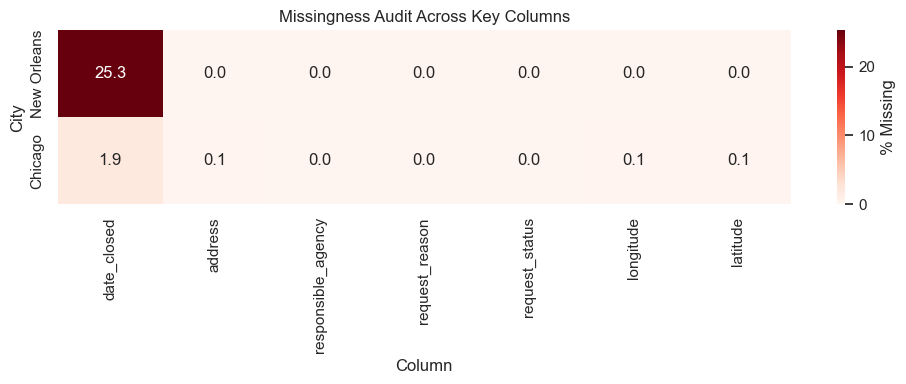

In [35]:

## Missingness audit for key columns in both datasets
nola_audit_cols = ['date_closed', 'address', 'responsible_agency','request_reason', 'request_status', 'longitude', 'latitude']
chi_audit_cols = ['date_closed', 'address', 'responsible_agency', 'request_reason', 'request_status', 'longitude', 'latitude']

### calculate percentage of missing values in each key column for both datasets
completeness_audit = pd.DataFrame({
    'New Orleans': nola_311[nola_audit_cols].isna().mean() * 100,
    'Chicago': chi_311[chi_audit_cols].isna().mean() * 100
}).rename_axis('column').reset_index()

completeness_audit

### create a heatmap to visualize the percentage of missing values in key columns for both cities
completeness_heatmap = completeness_audit.set_index('column').T

plt.figure(figsize=(10, 4))
sns.heatmap(completeness_heatmap, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': '% Missing'})
plt.title('Missingness Audit Across Key Columns')
plt.xlabel('Column')
plt.ylabel('City')
plt.tight_layout()
plt.show()



Date Closed seemed to be the most missing value which makes sense as that's the last one to get filled and requires completion of the request before being added. Other fields are usually filled at the time of teh creation of the request. However New Orleans has a much higher percentage of missing date_closed values compared to that of Chicago. New Orleans office needs to do some catching up.


### 1.3. Request Status Proportions

A simple bar graph can help us compare the proportions.

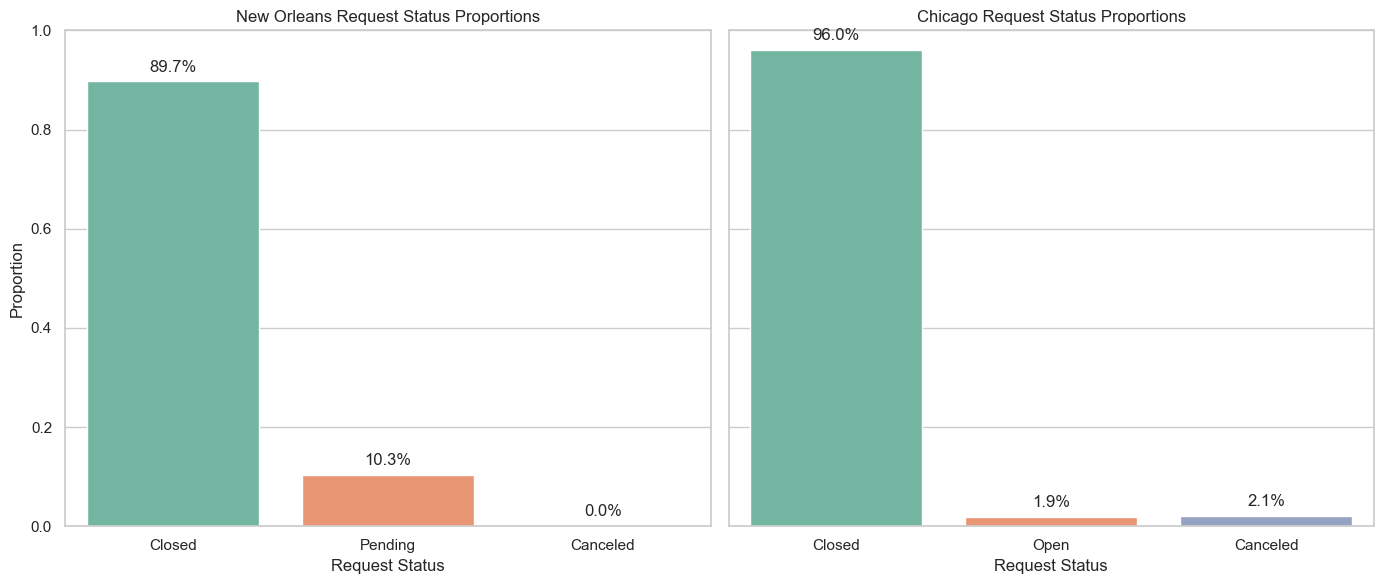

In [36]:
### compare the distribution of request_status values between the two cities, standardizing the status values to 'Closed', 'Pending', 'Canceled', and 'Open' for better comparison

status_order_nola = ['Closed', 'Pending', 'Canceled']
status_order_chi = ['Closed', 'Open', 'Canceled']

### calculate the proportion of each request_status value in both datasets
nola_status_compare = (
    nola_311['request_status']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
    .replace({'Completed': 'Closed'})
    .value_counts(normalize=True)
    .reindex(status_order_nola, fill_value=0)
    .rename_axis('request_status')
    .reset_index(name='proportion')
)
nola_status_compare['city'] = 'New Orleans'

chi_status_compare = (
    chi_311['request_status']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
    .replace({'Completed': 'Closed'})
    .value_counts(normalize=True)
    .reindex(status_order_chi, fill_value=0)
    .rename_axis('request_status')
    .reset_index(name='proportion')
)
chi_status_compare['city'] = 'Chicago'

### combine the status proportions for both cities into a single DataFrame for comparison
status_proportions_compare = pd.concat([nola_status_compare, chi_status_compare], ignore_index=True)
status_proportions_compare

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)


### create side-by-side bar plots comparing the proportion of each request_status value between New Orleans and Chicago
for ax, city in zip(axes, ['New Orleans', 'Chicago']):
    city_data = status_proportions_compare[status_proportions_compare['city'] == city]
    sns.barplot(data=city_data, x='request_status', y='proportion', hue='request_status', palette='Set2', legend=False, ax=ax)
    ax.set_title(f'{city} Request Status Proportions')
    ax.set_xlabel('Request Status')
    ax.set_ylabel('Proportion')
    ax.set_ylim(0, 1)
    for bar in ax.patches:
        height = bar.get_height()
        ax.annotate(f'{height:.1%}',
                    (bar.get_x() + bar.get_width() / 2, height),
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


As established earlier New Orleans has some catching up to do. Chicago seems to be doing pretty well given the sheer number of the requests they receive. 

We can see that Large item pickup is top request in New Orleans making up about ~16% of the data and aircraft noise for Chicago which is about ~27% of the requests. 


## Temporal Analysis

Temporal analysis can show really interesting things in the data the sort we are dealing with. Let's see how the request volume fluctuates over time.


### 2.1. Request Volume Trends Across the Months and Years (2020-2025)



I am going to use line graphs to plot the number of monthly incoming requests as they are easier to compare spikes. 

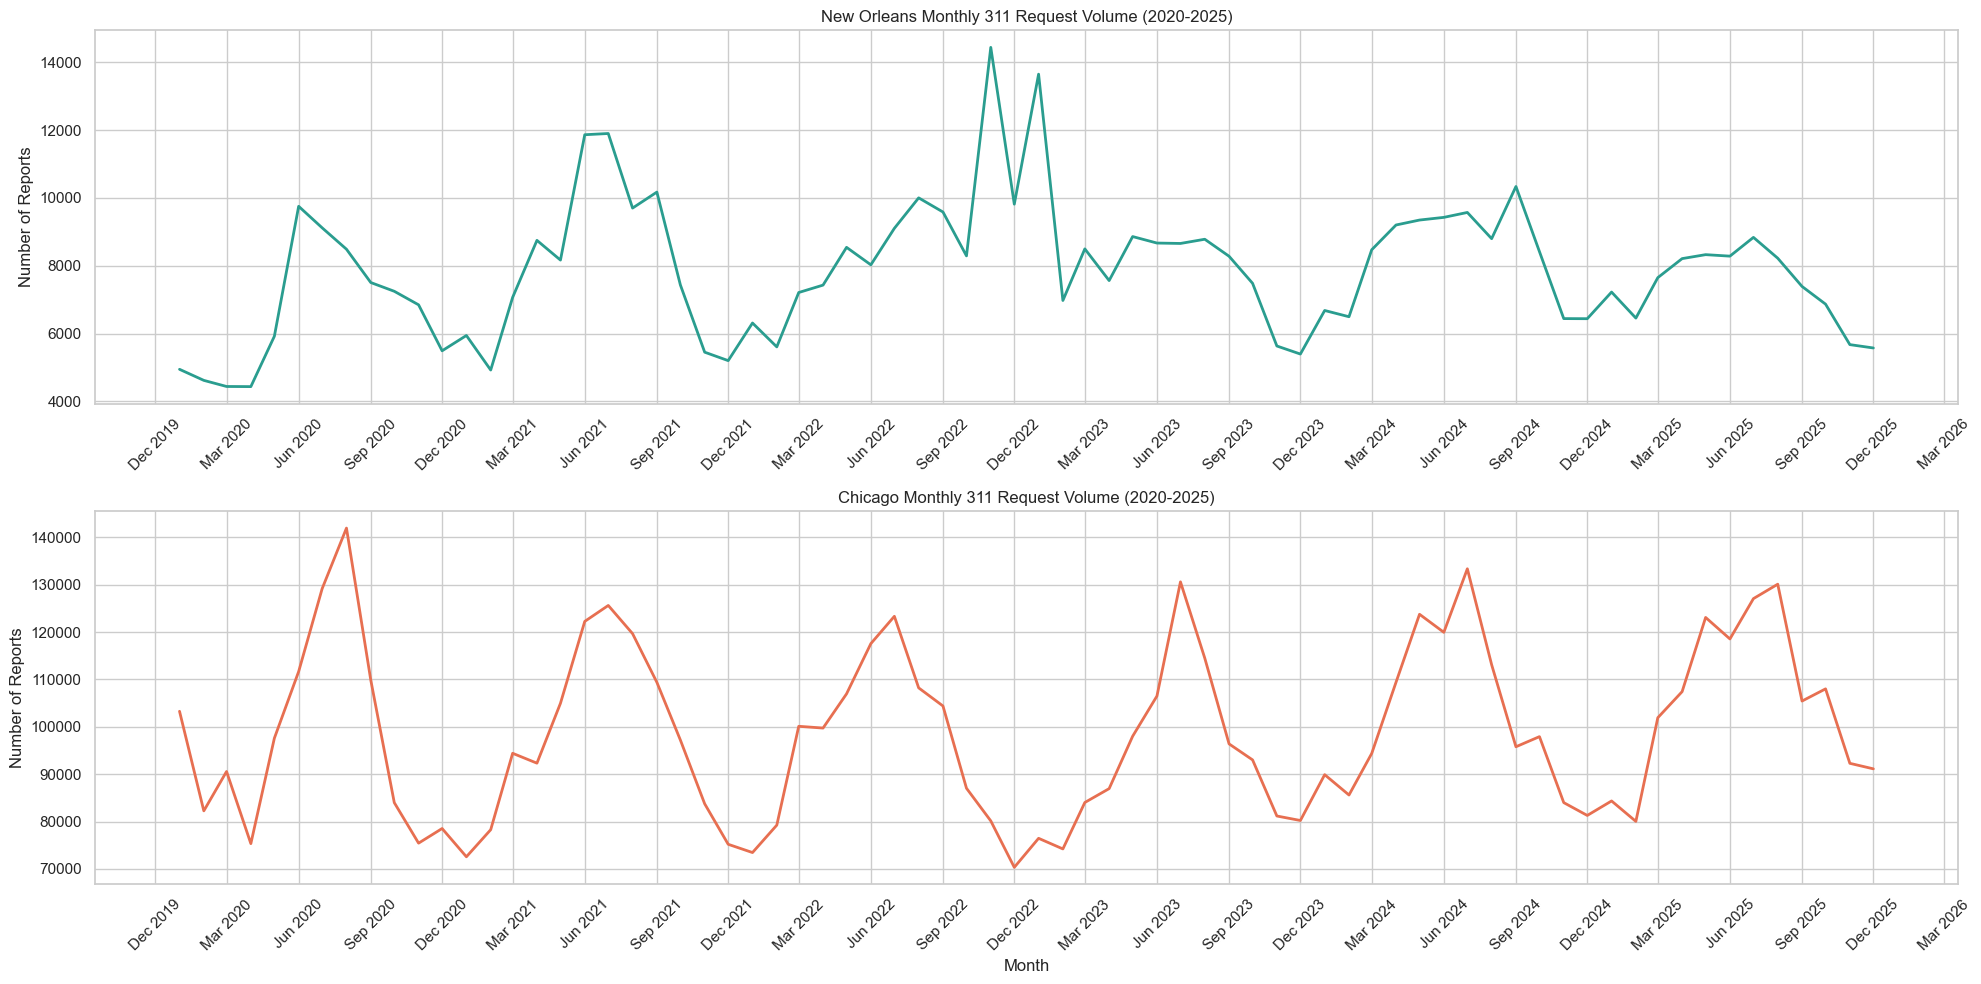

In [37]:
### New Orleans monthly trend

nola_monthly_trend = (
    nola_311[nola_311['date_created'].between('2020-01-01', '2025-12-31 23:59:59')]
    .assign(month=lambda df: df['date_created'].dt.to_period('M').dt.to_timestamp())
    .groupby('month')
    .size()
    .reset_index(name='report_count')
)
nola_monthly_trend['city'] = 'New Orleans'


### Chicago monthly trend
chi_monthly_trend = (
    chi_311[chi_311['date_created'].between('2020-01-01', '2025-12-31 23:59:59')]
    
    .assign(month=lambda df: df['date_created'].dt.to_period('M').dt.to_timestamp())
    .groupby('month')
    .size()
    .reset_index(name='report_count')
)
chi_monthly_trend['city'] = 'Chicago'

monthly_volume_trends = pd.concat([nola_monthly_trend, chi_monthly_trend], ignore_index=True)
monthly_volume_trends.head()

### plot line charts comparing the monthly 311 request volume trends between New Orleans and Chicago from January 2020 through December 2025, using the same x-axis
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=True)

colors = {'New Orleans': '#2a9d8f', 'Chicago': '#e76f51'}

for ax, city in zip(axes, ['New Orleans', 'Chicago']):
    city_data = monthly_volume_trends[monthly_volume_trends['city'] == city]
    sns.lineplot(
        data=city_data,
        x='month',
        y='report_count',
        color=colors[city],
        linewidth=2,
        ax=ax
    )
    ax.set_title(f'{city} Monthly 311 Request Volume (2020-2025)')
    ax.set_ylabel('Number of Reports')
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=45, labelbottom=True)

axes[0].set_xlabel('Month')
axes[1].set_xlabel('Month')

plt.tight_layout()
plt.show()



I notice that the summer months of June-September usually have the peak activity for the city of Chicago (like clockwork) and even for New Orleans! There are also some interesting peaks for New Orleans that may possibly point to something more. 

Let's also create a plot of averages for months across the five years. 

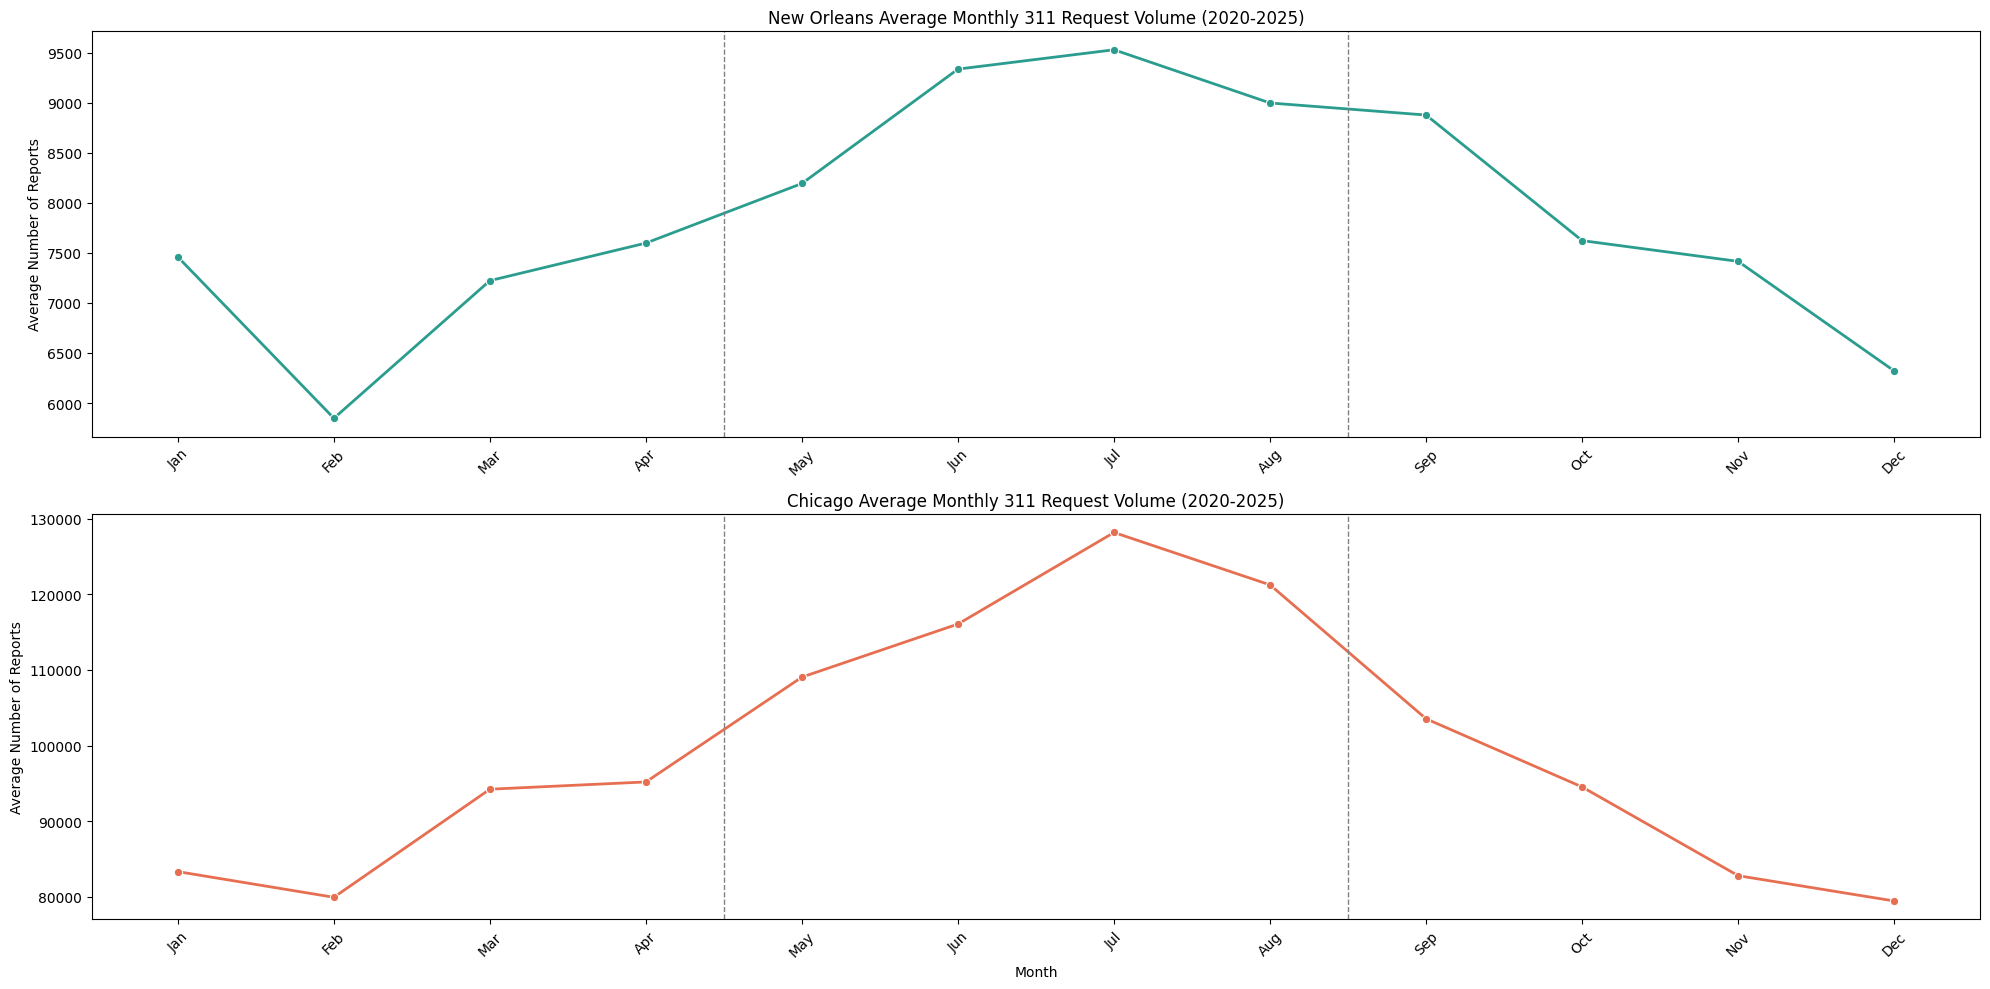

In [65]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

month_order = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

def average_monthly_reports(df, city_name):
    monthly_counts = (
        df[df['date_created'].between('2020-01-01', '2025-12-31 23:59:59')]
        .assign(
            year=lambda x: x['date_created'].dt.year,
            month_num=lambda x: x['date_created'].dt.month
        )
        .groupby(['year', 'month_num'])
        .size()
        .reset_index(name='report_count')
    )

    avg_monthly_counts = (
        monthly_counts.groupby('month_num')['report_count']
        .mean()
        .reset_index(name='avg_report_count')
    )
    avg_monthly_counts['city'] = city_name
    avg_monthly_counts['month_label'] = avg_monthly_counts['month_num'].map(
        dict(enumerate(month_order, start=1))
    )
    return avg_monthly_counts

nola_avg_monthly_reports = average_monthly_reports(nola_311, 'New Orleans')
chi_avg_monthly_reports = average_monthly_reports(chi_311, 'Chicago')

avg_monthly_volume = pd.concat(
    [nola_avg_monthly_reports, chi_avg_monthly_reports],
    ignore_index=True
)

fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=True)
colors = {'New Orleans': '#2a9d8f', 'Chicago': '#e76f51'}

for ax, city in zip(axes, ['New Orleans', 'Chicago']):
    city_data = avg_monthly_volume[avg_monthly_volume['city'] == city]
    sns.lineplot(
        data=city_data,
        x='month_num',
        y='avg_report_count',
        marker='o',
        color=colors[city],
        linewidth=2,
        ax=ax
    )
    ax.axvline(4.5, color='gray', linestyle='--', linewidth=1)
    ax.axvline(8.5, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'{city} Average Monthly 311 Request Volume (2020-2025)')
    ax.set_ylabel('Average Number of Reports')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_order)
    ax.tick_params(axis='x', rotation=45, labelbottom=True)

axes[0].set_xlabel('Month')
axes[1].set_xlabel('Month')

plt.tight_layout()
plt.show()


This confirms that the second trimester, essentially the summer, does see a surge in request volumes. This encourages my Hypothesis 1 investigation to establish a connection between the time of year and request composition but that's a later discussion. We need to see if there are signs of request composition changing.

Let's examine the number of reports under each request reason for the three trimesters of the year T1 (JAN-APR), T2 (MAY-AUG), and T3 (SEP-DEC).

### 2.2. Matching the activity with seasonal peaks or major events

Chicago Summer Peak Driving Factors

I am going to use a datafrmae here for visual inspection and access to details. 

In [80]:
### trimester request table for Chicago dataset to analyze the distribution of request reasons across trimesters, using the same trimester order for both datasets

trimester_order = ['T1', 'T2', 'T3']

chi_trimester_yearly = (
    chi_311.assign(
        year=chi_311['date_created'].dt.year,
        trimester=pd.cut(
            chi_311['date_created'].dt.month,
            bins=[0, 4, 8, 12],
            labels=trimester_order
        )
    )
    .groupby(['request_reason', 'year', 'trimester'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=trimester_order, fill_value=0)
    .reset_index()
)

chi_t2_totals_by_year = (
    chi_trimester_yearly.groupby('year', as_index=False)
    .agg(total_t2_requests=('T2', 'sum'))
)

chi_trimester_yearly = chi_trimester_yearly.merge(
    chi_t2_totals_by_year,
    on='year',
    how='left'
)

chi_trimester_yearly['pct_increase_t1_to_t2'] = (
    (chi_trimester_yearly['T2'] - chi_trimester_yearly['T1'])
    / chi_trimester_yearly['total_t2_requests'].replace(0, pd.NA)
) * 100

chi_trimester_percentage_summary = (
    chi_trimester_yearly.groupby('request_reason', as_index=False)
    .agg(
        avg_pct_increase_t1_to_t2=('pct_increase_t1_to_t2', 'mean')
    )
)

chi_trimester_request_table = (
    chi_trimester_yearly.groupby('request_reason')[trimester_order]
    .sum()
    .reset_index()
    .merge(chi_trimester_percentage_summary, on='request_reason', how='left')
)

chi_trimester_request_table = chi_trimester_request_table.sort_values(
    'avg_pct_increase_t1_to_t2',
    ascending=False
).reset_index(drop=True)

chi_trimester_request_table.head(20)


/var/folders/r0/6m_3dcrs53qf0lfygy7ffmwm0000gn/T/ipykernel_14450/2161863572.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['request_reason', 'year', 'trimester'])


,request_reason,T1,T2,T3,avg_pct_increase_t1_to_t2
0,Aircraft Noise Complaint,573417,700588,644569,4.503719
1,Weed Removal Request,419,89562,27839,3.122217
2,Tree Debris Clean-Up Request,19993,105210,42217,2.974820
3,Tree Emergency,12183,85893,26609,2.558053
4,Rodent Baiting/Rat Complaint,70960,137603,100163,2.342848
5,Tree Trim Request (NO LONGER BEING ACCEPTED),56255,99566,69809,1.595089
6,Garbage Cart Maintenance,83870,126861,93047,1.507397
7,Tree Removal Inspection,23562,55986,26914,1.134990
8,Water in Basement Complaint,9350,39923,9468,1.076768
9,Open Fire Hydrant Complaint,3038,32831,6542,1.047300


For starters, we see a massive increase in reports weed removal and tree debris clean up requests. We also see rodent, bat related issues moving from T1-T2. After winter months, animals and insects often come out of hibernation and are more visible. It also seems that there is a surgence in tree and weed cutting/removal requests in the second trimester of the year. This could be due to seasonal growth patterns, where trees and weeds grow more rapidly during the spring and summer months. Additionally, weather conditions such as increased rainfall and warmer temperatures can contribute to the proliferation of vegetation. We also see increase in incidents of flooded basements and streets in this T2.

### New Orleans Summer Peak Drivers

In [82]:
### creating a similar trimester request table for New Orleans dataset to compare the distribution of request reasons across trimesters between the two cities, using the same trimester order for both datasets

trimester_order = ['T1', 'T2', 'T3']

nola_trimester_yearly = (
    nola_311.assign(
        year=nola_311['date_created'].dt.year,
        trimester=pd.cut(
            nola_311['date_created'].dt.month,
            bins=[0, 4, 8, 12],
            labels=trimester_order
        )
    )
    .groupby(['request_reason', 'year', 'trimester'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=trimester_order, fill_value=0)
    .reset_index()
)

nola_t2_totals_by_year = (
    nola_trimester_yearly.groupby('year', as_index=False)
    .agg(total_t2_requests=('T2', 'sum'))
)

nola_trimester_yearly = nola_trimester_yearly.merge(
    nola_t2_totals_by_year,
    on='year',
    how='left'
)

nola_trimester_yearly['pct_increase_t1_to_t2'] = (
    (nola_trimester_yearly['T2'] - nola_trimester_yearly['T1'])
    / nola_trimester_yearly['total_t2_requests'].replace(0, pd.NA)
) * 100

nola_trimester_percentage_summary = (
    nola_trimester_yearly.groupby('request_reason', as_index=False)
    .agg(
        avg_pct_increase_t1_to_t2=('pct_increase_t1_to_t2', 'mean')
    )
)

nola_trimester_request_table = (
    nola_trimester_yearly.groupby('request_reason')[trimester_order]
    .sum()
    .reset_index()
    .merge(nola_trimester_percentage_summary, on='request_reason', how='left')
)

nola_trimester_request_table = nola_trimester_request_table.sort_values(
    'avg_pct_increase_t1_to_t2',
    ascending=False
).reset_index(drop=True)

nola_trimester_request_table.head(20)


/var/folders/r0/6m_3dcrs53qf0lfygy7ffmwm0000gn/T/ipykernel_14450/1142174461.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['request_reason', 'year', 'trimester'])


,request_reason,T1,T2,T3,avg_pct_increase_t1_to_t2
0,Property Maintenance,10266,20470,11567,4.693374
1,Request a Large Item Pick Up,27840,35230,28008,3.488204
2,Missed Trash Pick-Up,14678,20359,18389,2.302844
3,Request Tree Service (Right of Way/Public Prop...,2724,6246,5101,1.632329
4,Streetlight Outage/Malfunction,7929,10040,11043,0.968050
5,COVID-19 Business Non-Compliance,1698,3419,1791,0.930286
6,MIssed Recycling Pick-Up,5647,7879,4822,0.874934
7,Replace Trash Cart,7393,8949,8752,0.722704
8,Repair Trash Cart,7333,8842,7744,0.705131
9,Abandoned/Junk Vehicles,14593,16074,13659,0.680005


It seems that requests for property maintenance (potentially weed removal) and item/trash pickup increase in T2. We also see an increase in street and catch basin flooding related requests due to New Orleans receiving more rainfall in summer months [[3](https://www.usclimatedata.com/climate/new-orleans/louisiana/united-states/usla0338)].


That said, we know that New Orleans is unique due to its geography putting it inside area often impacted by hurricanes. The month-to-month chart for New Orleans has some interesting peaks that may be slightly out of place. I hypothesise that they are due to hurricane issues. 

There were two major hurricanes between 2020-2025. Let's dive deep!

### Hurricane Ida Daily Trace (New Orleans, Late 2021)

Let's start with Ida. I will use a line graph for the request activity with a marker to show Ida landfall and subsequent rise in requests. 

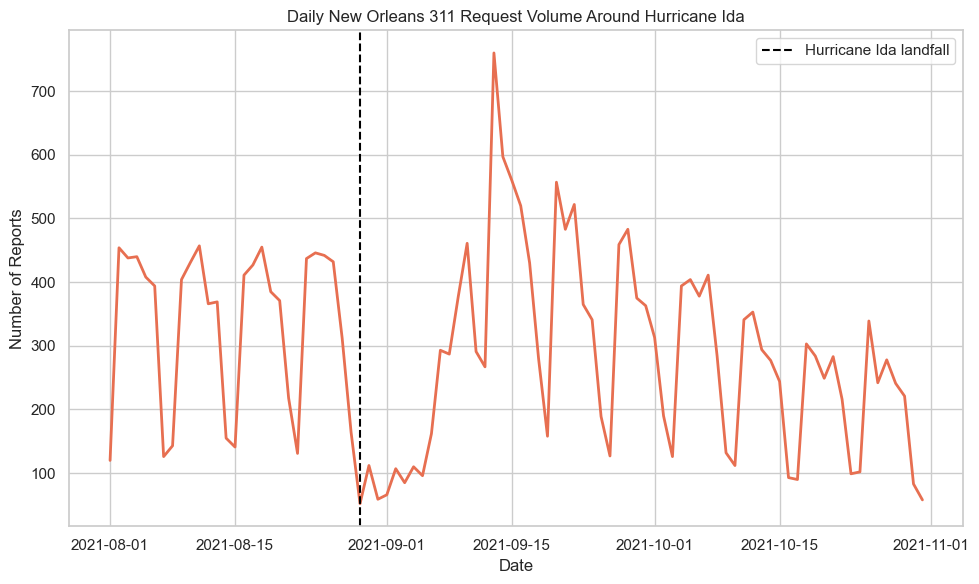

In [40]:
### ida trace from August 1, 2021 through October 31, 2021 to capture the period around Hurricane Ida's landfall on August 29, 2021, and analyze the impact of the hurricane on 311 request volume in New Orleans during that time frame

ida_trace = (
    nola_311[nola_311['date_created'].between('2021-08-01', '2021-10-31 23:59:59')]
    .assign(day=lambda df: df['date_created'].dt.floor('D'))
    .groupby('day')
    .size()
    .reset_index(name='report_count')
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=ida_trace, x='day', y='report_count', color='#e76f51', linewidth=2)
plt.axvline(pd.Timestamp('2021-08-29'), color='black', linestyle='--', linewidth=1.5, label='Hurricane Ida landfall')
plt.title('Daily New Orleans 311 Request Volume Around Hurricane Ida')
plt.xlabel('Date')
plt.ylabel('Number of Reports')
plt.legend()
plt.tight_layout()
plt.show()


My educated guess is, with the onset of IDA there was a drop in number of requests most likely due to severe weather warnings compelling people to leave the city, which followed by massive increase in number of daily requests as people returned to their homes. 

### Hurricane Francine Daily Trace (New Orleans, Late 2024)

Now lets look at how Francine impacted the activity. I will use a similar line graph with a marker to show francine landfall. 

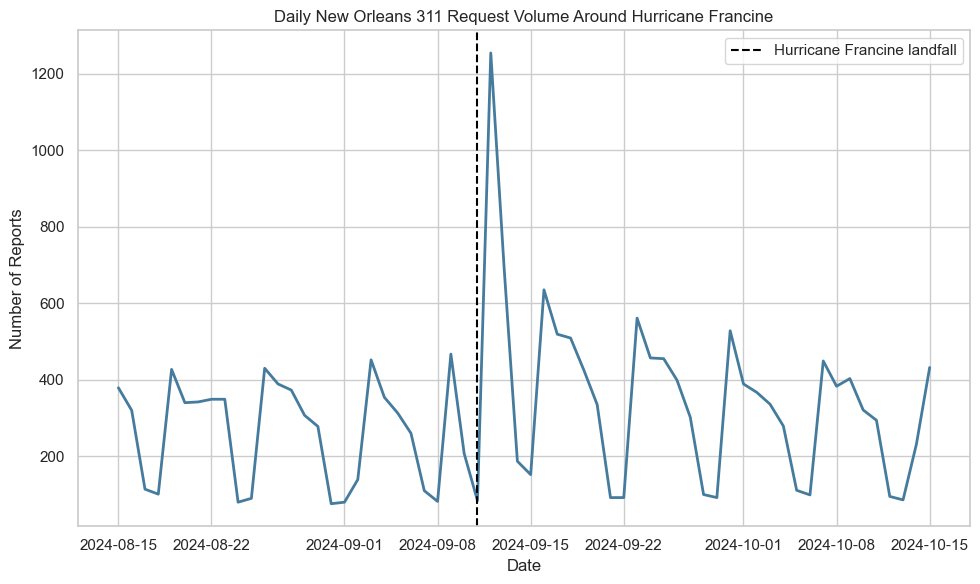

In [41]:
### francine trace from August 15, 2024 through October 15, 2024 to capture the period around Hurricane Francine's landfall on September 11, 2024, and analyze the impact of the hurricane on 311 request volume in New Orleans during that time frame
francine_trace = (
    nola_311[nola_311['date_created'].between('2024-08-15', '2024-10-15 23:59:59')]
    .assign(day=lambda df: df['date_created'].dt.floor('D'))
    .groupby('day')
    .size()
    .reset_index(name='report_count')
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=francine_trace, x='day', y='report_count', color='#457b9d', linewidth=2)
plt.axvline(pd.Timestamp('2024-09-11'), color='black', linestyle='--', linewidth=1.5, label='Hurricane Francine landfall')
plt.title('Daily New Orleans 311 Request Volume Around Hurricane Francine')
plt.xlabel('Date')
plt.ylabel('Number of Reports')
plt.legend()
plt.tight_layout()
plt.show()


For Francine, while there is a sharp peak, it occurs the next day of the hurricane impact day. Francine's impact was the greatest on the first day and weather went back to being okay the next day which corroborates with 

### 2.3. Categorical and Content Analysis

Let's check what are the top requests received by the city and infer what it says about the city dynamics! I am going to create comparison tables for this for a more detailed view. 

Let's take a look at the top requests the two cities received over the period of 5 years. 

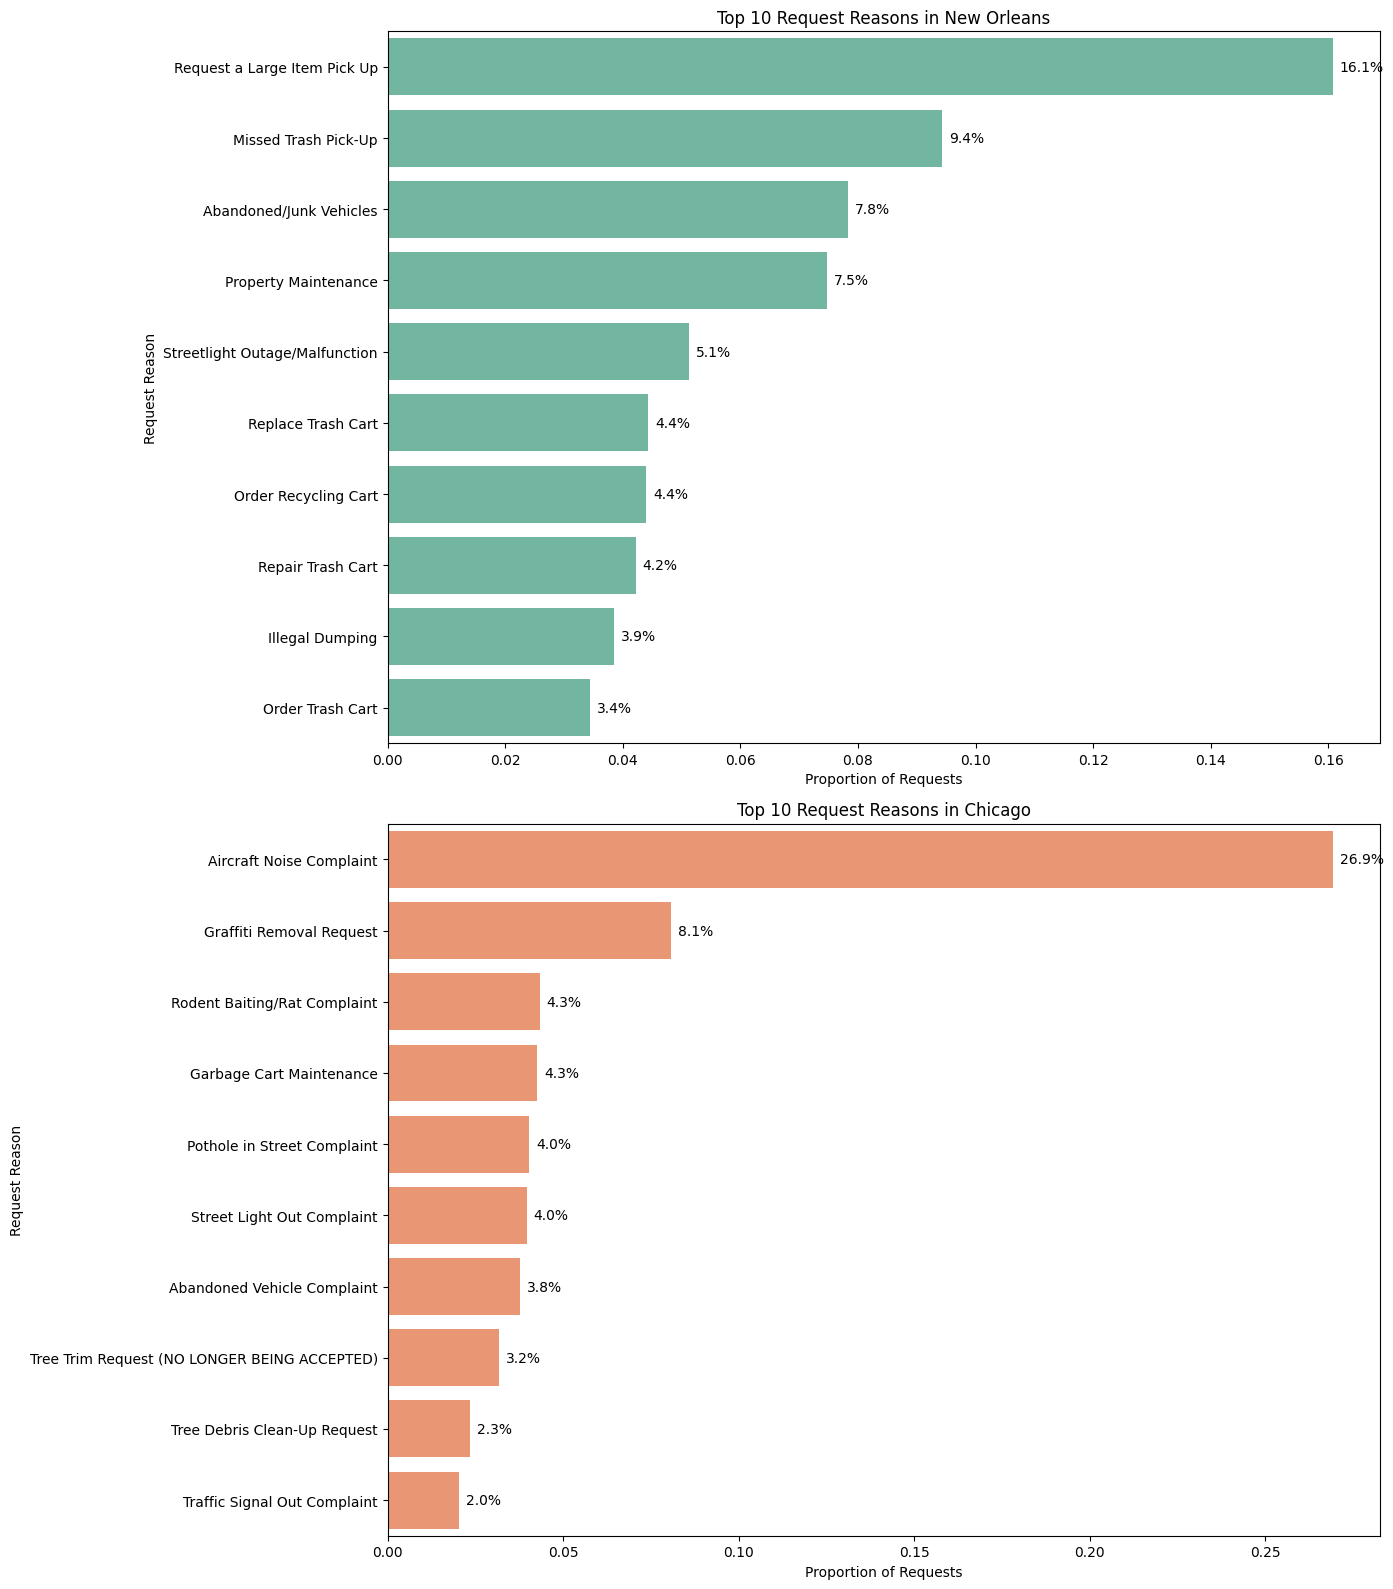

In [84]:
### top 10 most common request reasons in each city with percentage 
nola_top_reasons = (
    nola_311['request_reason']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
    .value_counts(normalize=True)
    .head(10)
    .rename_axis('request_reason')
    .reset_index(name='proportion')
)
nola_top_reasons['city'] = 'New Orleans'

chi_top_reasons = (
    chi_311['request_reason']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
    .value_counts(normalize=True)
    .head(10)
    .rename_axis('request_reason')
    .reset_index(name='proportion')
)
chi_top_reasons['city'] = 'Chicago'

fig, axes = plt.subplots(2, 1, figsize=(14, 16), sharex=False)

sns.barplot(
    data=nola_top_reasons,
    y='request_reason',
    x='proportion',
    color=sns.color_palette('Set2')[0],
    ax=axes[0]
)
axes[0].set_title('Top 10 Request Reasons in New Orleans')
axes[0].set_xlabel('Proportion of Requests')
axes[0].set_ylabel('Request Reason')

sns.barplot(
    data=chi_top_reasons,
    y='request_reason',
    x='proportion',
    color=sns.color_palette('Set2')[1],
    ax=axes[1]
)
axes[1].set_title('Top 10 Request Reasons in Chicago')
axes[1].set_xlabel('Proportion of Requests')
axes[1].set_ylabel('Request Reason')

for ax in axes:
    for bar in ax.patches:
        width = bar.get_width()
        ax.annotate(
            f'{width:.1%}',
            (width, bar.get_y() + bar.get_height() / 2),
            ha='left',
            va='center',
            xytext=(5, 0),
            textcoords='offset points'
        )

plt.tight_layout()
plt.show()


We can generally see that New Orleans top requests have to do a lot with sanitation. On the other hand, Chicago problems have a mix bag with some sanitation, and maintenace requests. 


### 3. Service Performance and Spatial Equity

I am interested in seeing if median is a significant indicator and differing feature in the datasets and whether I should include it as a temporal feature in my data. I am also generally interested in the median just to better compare the performance of the two citiies. 

### 3.1. Resolution Time Distribution

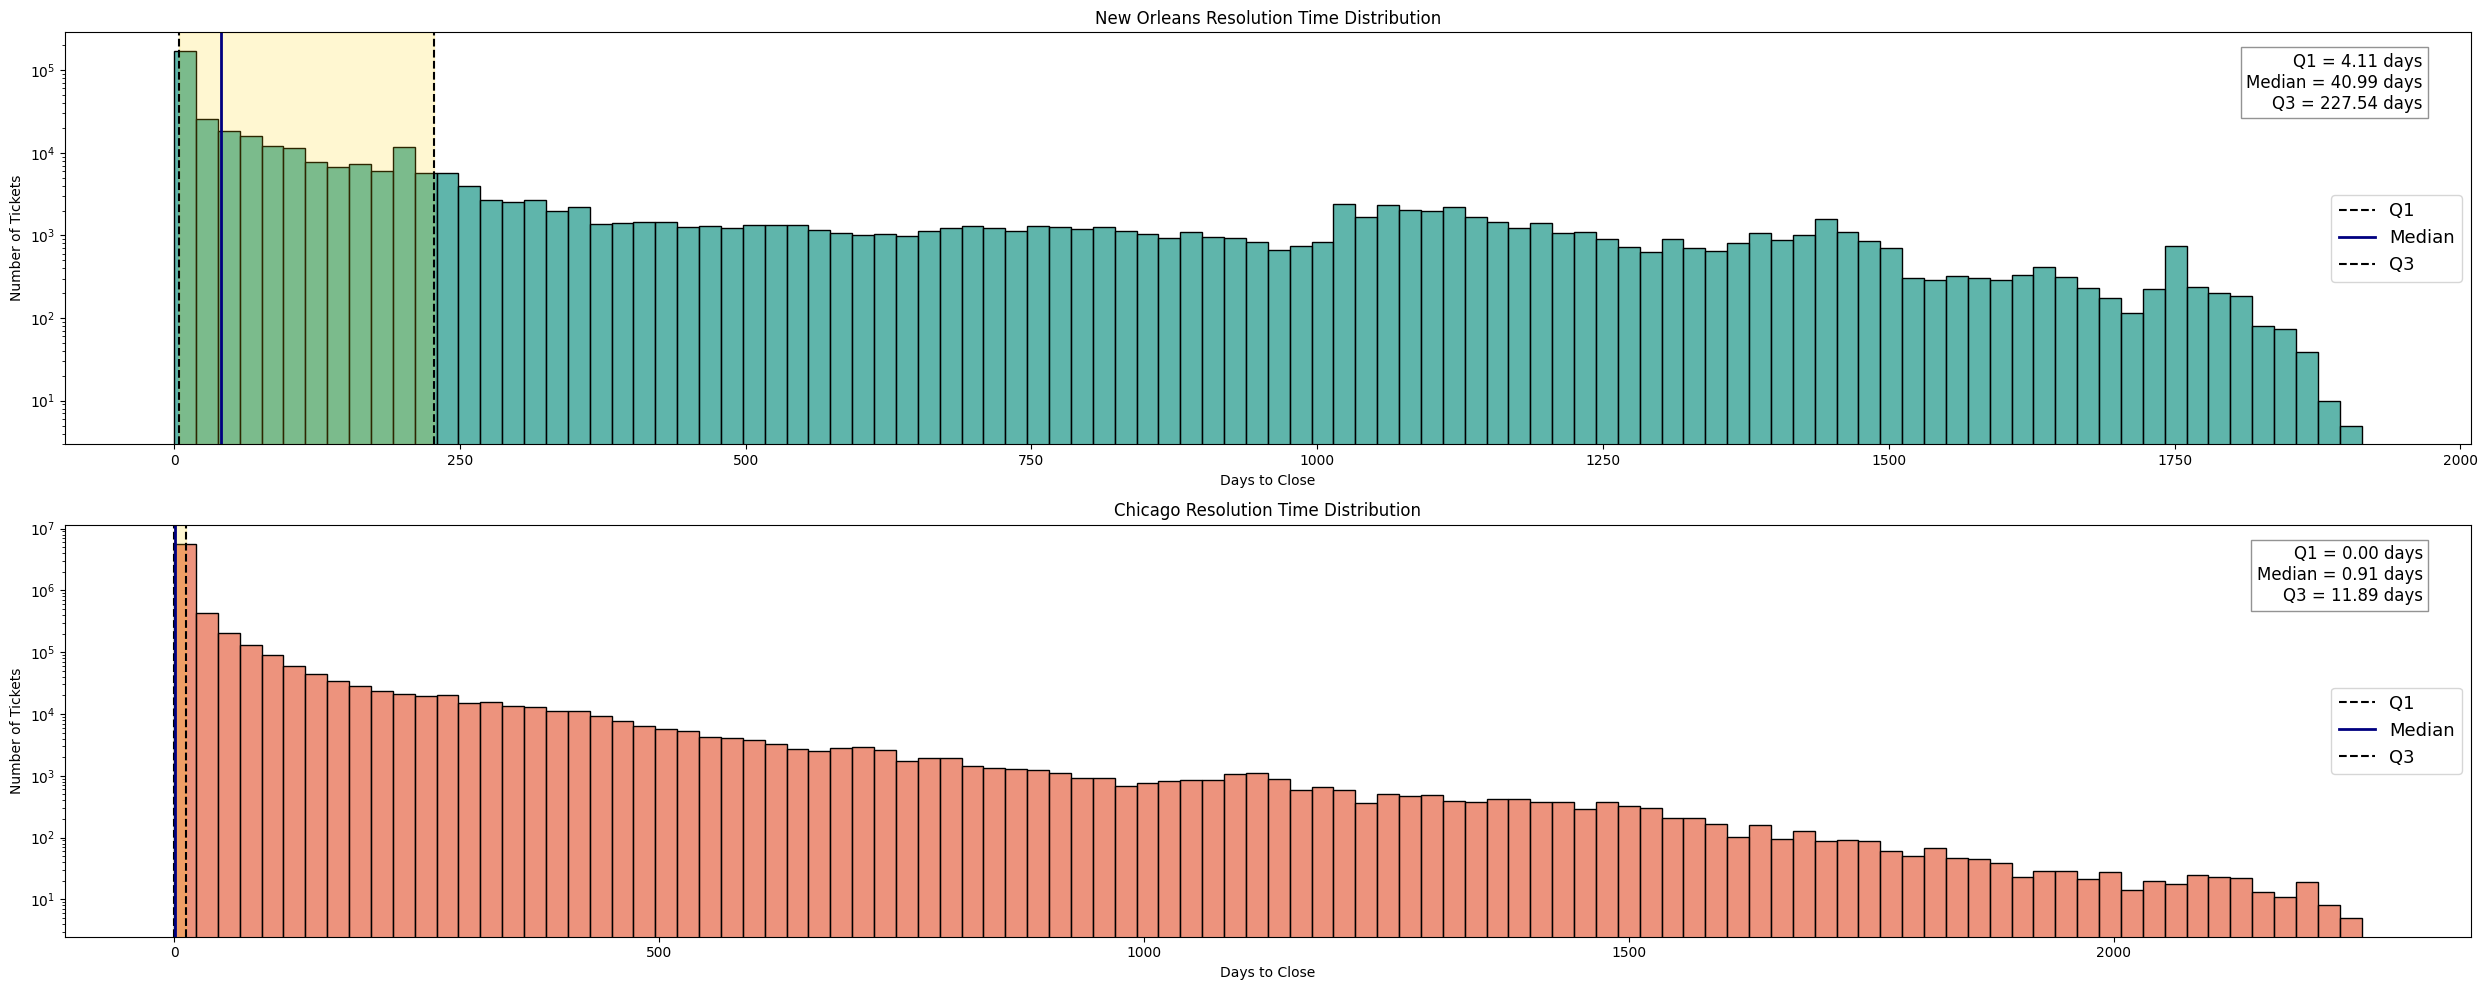

In [85]:
### compare the distribution of time to close requests between the two cities, focusing on resolved requests where date_closed is after date_created, and calculating the time to close in days for each resolved request

nola_resolved = nola_311[(nola_311['date_closed'].notna()) & (nola_311['date_closed'] >= nola_311['date_created'])].copy()
chi_resolved = chi_311[(chi_311['date_closed'].notna()) & (chi_311['date_closed'] >= chi_311['date_created'])].copy()

nola_resolved['time_to_close_days'] = (nola_resolved['date_closed'] - nola_resolved['date_created']).dt.total_seconds() / 86400
chi_resolved['time_to_close_days'] = (chi_resolved['date_closed'] - chi_resolved['date_created']).dt.total_seconds() / 86400

nola_q1, nola_median, nola_q3 = nola_resolved['time_to_close_days'].quantile([0.25, 0.5, 0.75])
chi_q1, chi_median, chi_q3 = chi_resolved['time_to_close_days'].quantile([0.25, 0.5, 0.75])

fig, axes = plt.subplots(2, 1, figsize=(25, 10), sharex=False)

sns.histplot(nola_resolved['time_to_close_days'], bins=100, color='#2a9d8f', ax=axes[0])
axes[0].axvspan(nola_q1, nola_q3, color='gold', alpha=0.18)
axes[0].axvline(nola_q1, color='black', linestyle='--', linewidth=1.5, label='Q1')
axes[0].axvline(nola_median, color='navy', linestyle='-', linewidth=2, label='Median')
axes[0].axvline(nola_q3, color='black', linestyle='--', linewidth=1.5, label='Q3')
axes[0].text(
    0.98, 0.95,
    f'Q1 = {nola_q1:.2f} days\nMedian = {nola_median:.2f} days\nQ3 = {nola_q3:.2f} days',
    transform=axes[0].transAxes,
    ha='right',
    va='top',
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray')
)
axes[0].set_title('New Orleans Resolution Time Distribution')
axes[0].set_xlabel('Days to Close')
axes[0].set_ylabel('Number of Tickets')
axes[0].set_yscale('log')
axes[0].legend(fontsize=13, title_fontsize=14)

sns.histplot(chi_resolved['time_to_close_days'], bins=100, color='#e76f51', ax=axes[1])
axes[1].axvspan(chi_q1, chi_q3, color='gold', alpha=0.18)
axes[1].axvline(chi_q1, color='black', linestyle='--', linewidth=1.5, label='Q1')
axes[1].axvline(chi_median, color='navy', linestyle='-', linewidth=2, label='Median')
axes[1].axvline(chi_q3, color='black', linestyle='--', linewidth=1.5, label='Q3')
axes[1].text(
    0.98, 0.95,
    f'Q1 = {chi_q1:.2f} days\nMedian = {chi_median:.2f} days\nQ3 = {chi_q3:.2f} days',
    transform=axes[1].transAxes,
    ha='right',
    va='top',
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray')
)
axes[1].set_title('Chicago Resolution Time Distribution')
axes[1].set_xlabel('Days to Close')
axes[1].set_ylabel('Number of Tickets')
axes[1].set_yscale('log')
axes[1].legend(fontsize=13, title_fontsize=14)

plt.tight_layout()
plt.show()


The Chicago dataset seems to feature a steady slope that decreases as the days to close progress. It's very right skewed. This is good, as it shows that most requests are closed sooner. As for the New Orleans data, while it starts as a downward slop, it pretty much stabilizes which means that requests on average take longer to be closed and a higher proportion of requests take longer compared to that in Chicago. 

I would also be interested in seeing the median time by request for top requests to see if there are reasons to worry that the median time might be skewed by some outliers. 

#### Median time for resolution by top 10 request type 

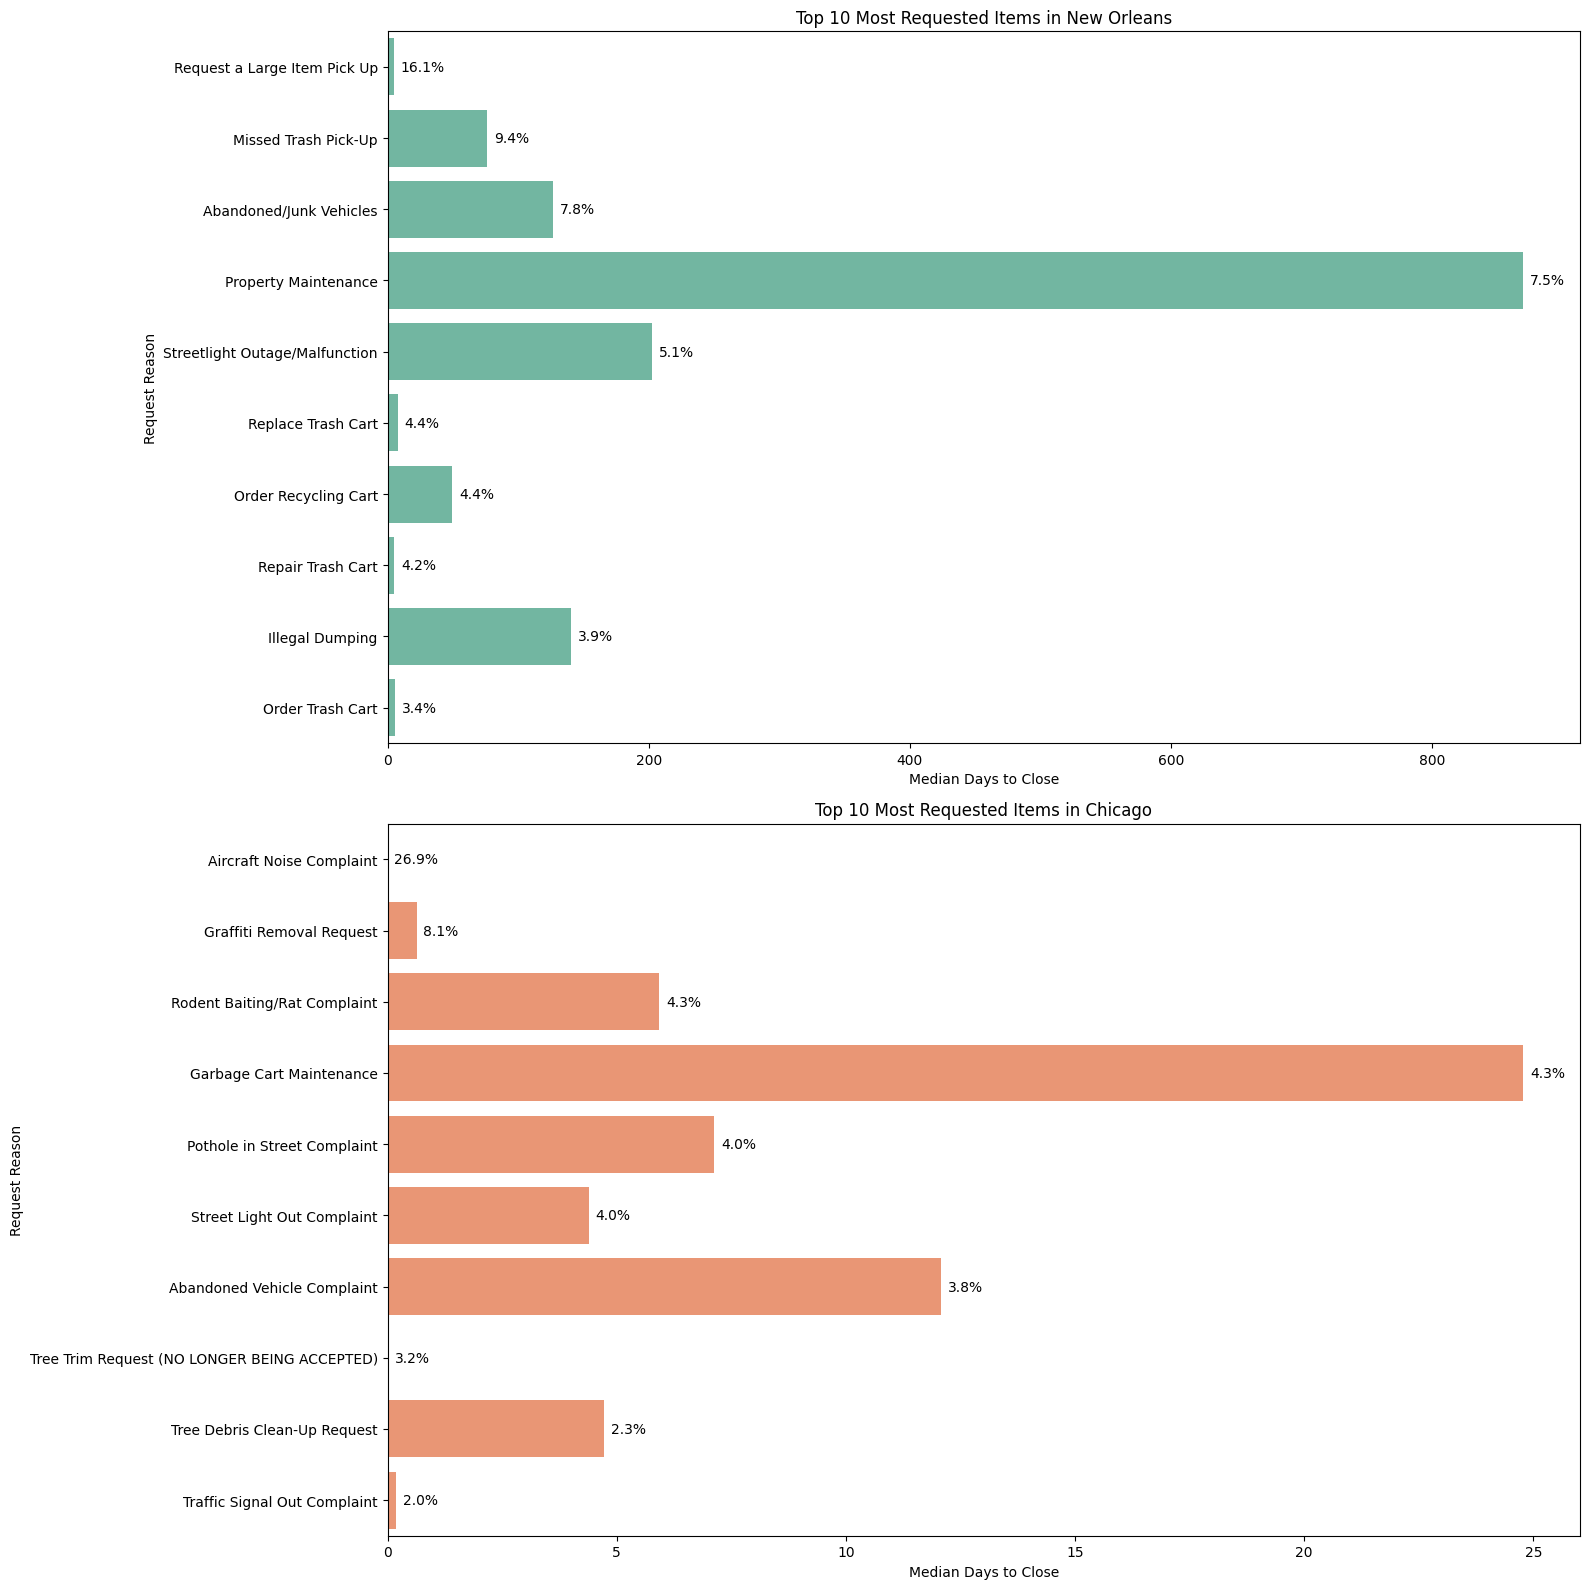

In [94]:
### top 10 most requested items with their median time to close and share of total requests

def build_top_request_summary(all_requests_df, resolved_requests_df, city_name):
    top_request_counts = (
        all_requests_df['request_reason']
        .fillna('Unknown')
        .astype(str)
        .str.strip()
        .value_counts()
        .head(10)
        .rename_axis('request_reason')
        .reset_index(name='request_count')
    )

    top_request_counts['proportion_of_total_requests'] = (
        top_request_counts['request_count'] / len(all_requests_df)
    ) * 100

    median_close_times = (
        resolved_requests_df.groupby('request_reason', as_index=False)['time_to_close_days']
        .median()
        .rename(columns={'time_to_close_days': 'median_time_to_close_days'})
    )

    top_request_summary = top_request_counts.merge(
        median_close_times,
        on='request_reason',
        how='left'
    )
    top_request_summary['city'] = city_name
    return top_request_summary

nola_top_request_summary = build_top_request_summary(
    nola_311,
    nola_resolved,
    'New Orleans'
)

chi_top_request_summary = build_top_request_summary(
    chi_311,
    chi_resolved,
    'Chicago'
)


fig, axes = plt.subplots(2, 1, figsize=(16, 16), sharex=False)
# Bar length shows median days to close, while the annotation shows each request type's share of total requests.
colors = {'New Orleans': sns.color_palette('Set2')[0], 'Chicago': sns.color_palette('Set2')[1]}

for ax, city_name, city_df in zip(
    axes,
    ['New Orleans', 'Chicago'],
    [nola_top_request_summary, chi_top_request_summary]
):
    sns.barplot(
        data=city_df,
        y='request_reason',
        x='median_time_to_close_days',
        color=colors[city_name],
        ax=ax
    )
    ax.set_title(f'Top 10 Most Requested Items in {city_name}')
    ax.set_xlabel('Median Days to Close')
    ax.set_ylabel('Request Reason')

    for bar, (_, row) in zip(ax.patches, city_df.iterrows()):
        width = bar.get_width()
        ax.annotate(
            f"{row['proportion_of_total_requests']:.1f}%",
            (width, bar.get_y() + bar.get_height() / 2),
            ha='left',
            va='center',
            xytext=(5, 0),
            textcoords='offset points'
        )

plt.tight_layout()
plt.show()


It seems that the top requests might be playing a role in skewing the median time, especially for Aircraft Nouse Complaints which essentialy have a median time of 0 days and make up a whopping 25% of the requests submitted to the Chicago 311 office. It seems that including median as a feature for the model might help.

For median sake, I would like to calculate the medians again without the aircraft noise complaints potentially skewing the median massively.

#### Resolution Time Distribution With Aircraft Noise Complaint Removed From Chicago

This cell recreates the resolution-time histogram comparison, but removes **Aircraft Noise Complaint** from the Chicago data before calculating resolution times and plotting the Chicago distribution.


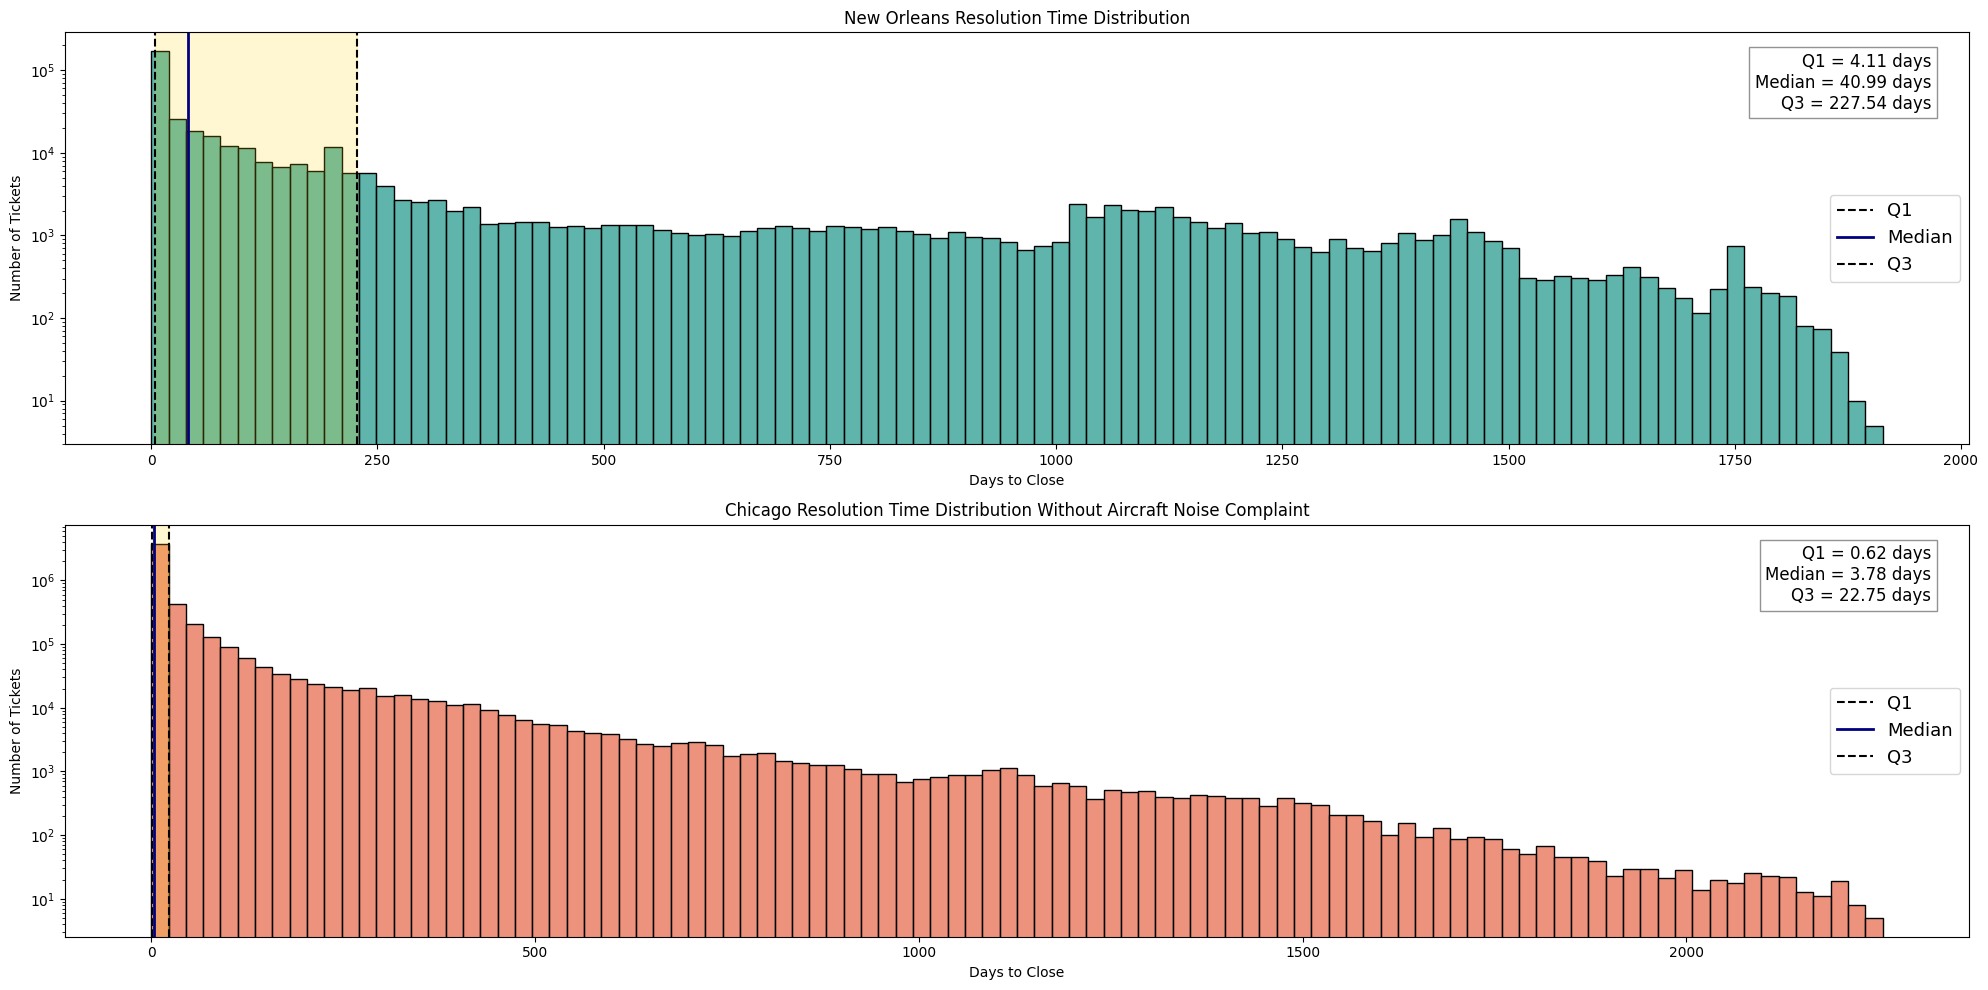

In [95]:
nola_resolved = nola_311[(nola_311['date_closed'].notna()) & (nola_311['date_closed'] >= nola_311['date_created'])].copy()
chi_resolved_no_aircraft = chi_311[
    (chi_311['date_closed'].notna())
    & (chi_311['date_closed'] >= chi_311['date_created'])
    & (~chi_311['request_reason'].str.contains('Aircraft Noise Complaint', case=False, na=False))
].copy()

nola_resolved['time_to_close_days'] = (nola_resolved['date_closed'] - nola_resolved['date_created']).dt.total_seconds() / 86400
chi_resolved_no_aircraft['time_to_close_days'] = (chi_resolved_no_aircraft['date_closed'] - chi_resolved_no_aircraft['date_created']).dt.total_seconds() / 86400

nola_q1, nola_median, nola_q3 = nola_resolved['time_to_close_days'].quantile([0.25, 0.5, 0.75])
chi_q1, chi_median, chi_q3 = chi_resolved_no_aircraft['time_to_close_days'].quantile([0.25, 0.5, 0.75])

fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=False)

sns.histplot(nola_resolved['time_to_close_days'], bins=100, color='#2a9d8f', ax=axes[0])
axes[0].axvspan(nola_q1, nola_q3, color='gold', alpha=0.18)
axes[0].axvline(nola_q1, color='black', linestyle='--', linewidth=1.5, label='Q1')
axes[0].axvline(nola_median, color='navy', linestyle='-', linewidth=2, label='Median')
axes[0].axvline(nola_q3, color='black', linestyle='--', linewidth=1.5, label='Q3')
axes[0].text(
    0.98, 0.95,
    f'Q1 = {nola_q1:.2f} days\nMedian = {nola_median:.2f} days\nQ3 = {nola_q3:.2f} days',
    transform=axes[0].transAxes,
    ha='right',
    va='top',
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray')
)
axes[0].set_title('New Orleans Resolution Time Distribution')
axes[0].set_xlabel('Days to Close')
axes[0].set_ylabel('Number of Tickets')
axes[0].set_yscale('log')
axes[0].legend(fontsize=13, title_fontsize=14)

sns.histplot(chi_resolved_no_aircraft['time_to_close_days'], bins=100, color='#e76f51', ax=axes[1])
axes[1].axvspan(chi_q1, chi_q3, color='gold', alpha=0.18)
axes[1].axvline(chi_q1, color='black', linestyle='--', linewidth=1.5, label='Q1')
axes[1].axvline(chi_median, color='navy', linestyle='-', linewidth=2, label='Median')
axes[1].axvline(chi_q3, color='black', linestyle='--', linewidth=1.5, label='Q3')
axes[1].text(
    0.98, 0.95,
    f'Q1 = {chi_q1:.2f} days\nMedian = {chi_median:.2f} days\nQ3 = {chi_q3:.2f} days',
    transform=axes[1].transAxes,
    ha='right',
    va='top',
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray')
)
axes[1].set_title('Chicago Resolution Time Distribution Without Aircraft Noise Complaint')
axes[1].set_xlabel('Days to Close')
axes[1].set_ylabel('Number of Tickets')
axes[1].set_yscale('log')
axes[1].legend(fontsize=13, title_fontsize=14)

plt.tight_layout()
plt.show()


The median time has now increased to 3.78 days from the previous 0.91 day! I think this figure maybe more realistic to the turnarounf time in Chicago.

Now lets sugue into geographical distribution of requests in these cities and how do districts in New Orleans and precincts in Chicago fare. This would be helpful in seeing if the geographical unit would be helpful feature to use in my predictive model!

### 3.2. Efficiency by District and Precinct

Let's check the median days to close by district (Nola) and precinct (Chicago). 

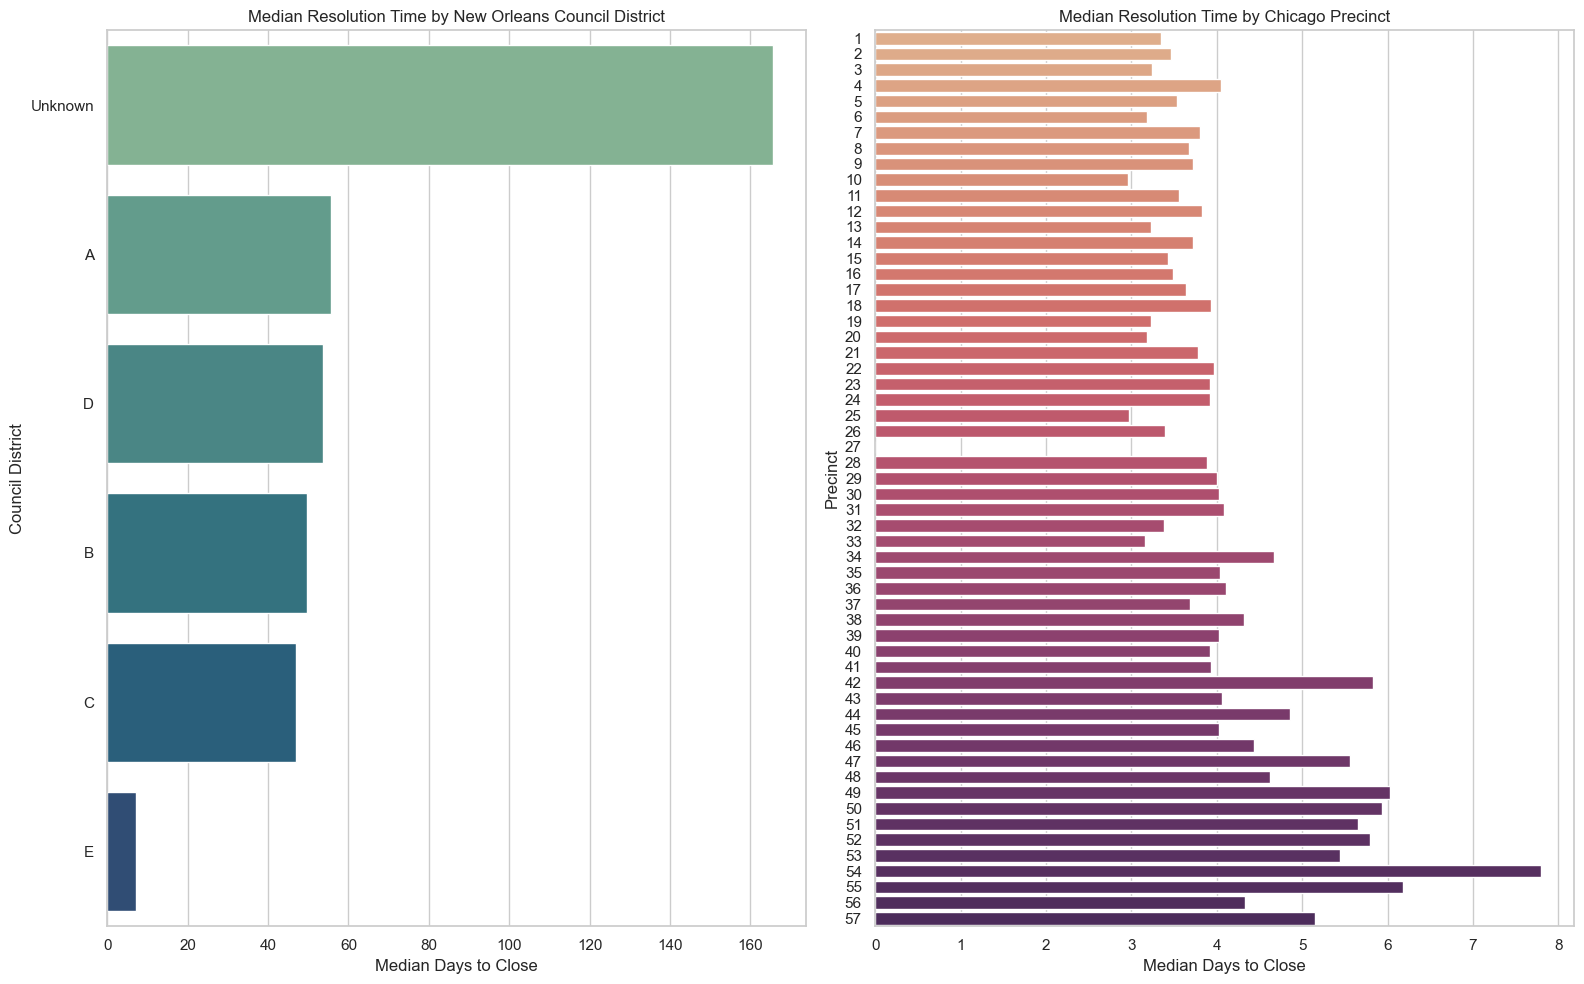

In [47]:
### compare the median time to close requests by district in New Orleans and by precinct in Chicago 


### calculate the median time to close requests by council district in New Orleans, excluding records with missing council district values, and sort the results in descending order to identify which districts have the longest resolution times
nola_district_efficiency = (
    nola_resolved[nola_resolved['council_district'].notna()]
    .groupby('council_district')['time_to_close_days']
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

### calculate the median time to close requests by precinct in Chicago, excluding records with missing precinct values, converting precinct values to numeric for proper sorting, and sorting the results in ascending order to identify which precincts have the shortest resolution times
chi_precinct_efficiency = (
    chi_resolved[chi_resolved['precinct'].notna()]
    .assign(precinct=pd.to_numeric(chi_resolved.loc[chi_resolved['precinct'].notna(), 'precinct'], errors='coerce'))
    .dropna(subset=['precinct'])
    .groupby('precinct')['time_to_close_days']
    .median()
    .reset_index()
)

### convert precinct values back to string for better visualization in the bar plot

chi_precinct_efficiency['precinct'] = chi_precinct_efficiency['precinct'].astype(int).astype(str)
precinct_order = sorted(chi_precinct_efficiency['precinct'].unique(), key=lambda x: int(x))

fig, axes = plt.subplots(1, 2, figsize=(16, 10))


### create side-by-side bar plots comparing the median time to close requests by council district in New Orleans and by precinct in Chicago
sns.barplot(
    data=nola_district_efficiency,
    x='time_to_close_days',
    y='council_district',
    hue='council_district',
    palette='crest',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Median Resolution Time by New Orleans Council District')
axes[0].set_xlabel('Median Days to Close')
axes[0].set_ylabel('Council District')

sns.barplot(
    data=chi_precinct_efficiency,
    x='time_to_close_days',
    y='precinct',
    order=precinct_order,
    hue='precinct',
    hue_order=precinct_order,
    palette='flare',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Median Resolution Time by Chicago Precinct')
axes[1].set_xlabel('Median Days to Close')
axes[1].set_ylabel('Precinct')

plt.tight_layout()
plt.show()



Before saying anything I will also like to check the number of reports from each district/precincts. 

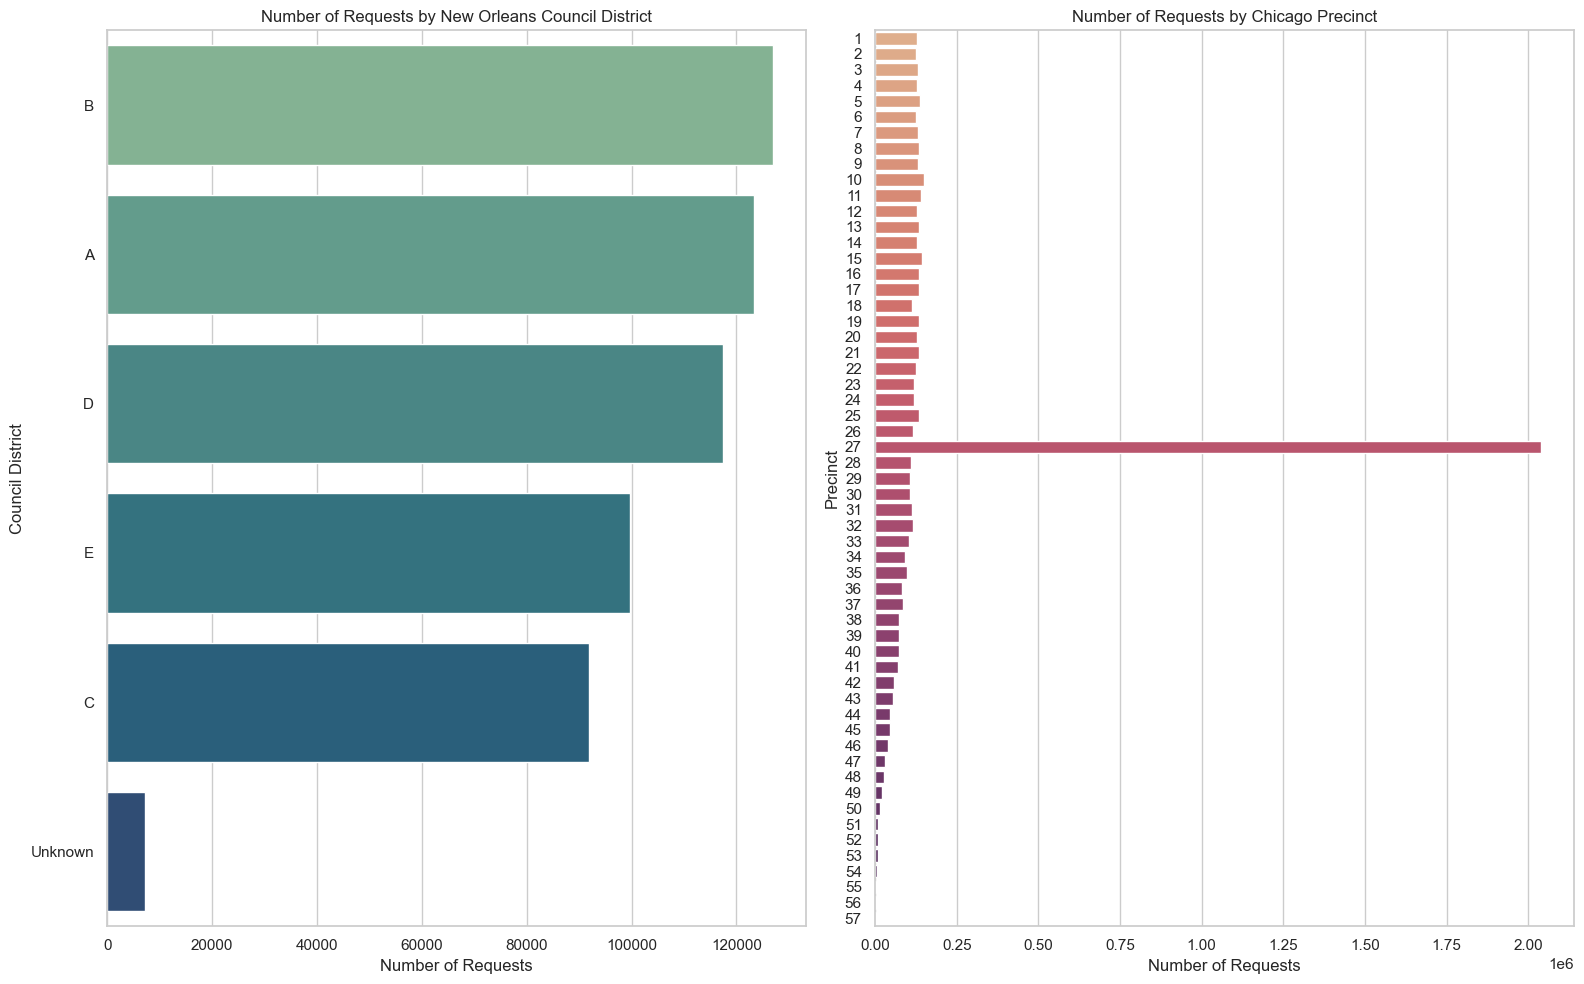

In [48]:
### grouping the New Orleans dataset by council district and counting the number of requests for each district
nola_district_counts = (
    nola_311[nola_311['council_district'].notna()]
    .groupby('council_district')
    .size()
    .reset_index(name='request_count')
    .sort_values('request_count', ascending=False)
)


### grouping the Chicago dataset by precinct, counting the number of requests for each precinct, converting precinct values to numeric for proper sorting, and sorting the results in ascending order to identify which precincts have the highest request volumes
chi_precinct_counts = (
    chi_311[chi_311['precinct'].notna()]
    .assign(precinct=pd.to_numeric(chi_311.loc[chi_311['precinct'].notna(), 'precinct'], errors='coerce'))
    .dropna(subset=['precinct'])
    .groupby('precinct')
    .size()
    .reset_index(name='request_count')
)

chi_precinct_counts['precinct'] = chi_precinct_counts['precinct'].astype(int).astype(str)
precinct_order = sorted(chi_precinct_counts['precinct'].unique(), key=lambda x: int(x))

fig, axes = plt.subplots(1, 2, figsize=(16, 10))


### create side-by-side bar plots comparing the number of requests by council district in New Orleans and by precinct in Chicago
sns.barplot(
    data=nola_district_counts,
    x='request_count',
    y='council_district',
    hue='council_district',
    palette='crest',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Number of Requests by New Orleans Council District')
axes[0].set_xlabel('Number of Requests')
axes[0].set_ylabel('Council District')

sns.barplot(
    data=chi_precinct_counts,
    x='request_count',
    y='precinct',
    order=precinct_order,
    hue='precinct',
    hue_order=precinct_order,
    palette='flare',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Number of Requests by Chicago Precinct')
axes[1].set_xlabel('Number of Requests')
axes[1].set_ylabel('Precinct')

plt.tight_layout()
plt.show()


The median and number of requests for precinct 27 is highly odd, with very high request rate and very low median. I would like to see what the request composition is like for this precinct to see if there's something up.

#### Precinct 27 investigation into request composition 

In [102]:
### precinct 27 top requests and proportion of each request reason among all requests in precinct 27
precinct_27_requests = chi_311[pd.to_numeric(chi_311['precinct'], errors='coerce') == 27]
precinct_27_reason_counts = (
    precinct_27_requests['request_reason']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
    .value_counts()
    .reset_index(name='request_count')
    .rename(columns={'index': 'request_reason'})
)
precinct_27_reason_counts['proportion_of_precinct_27_requests'] = (
    precinct_27_reason_counts['request_count'] / len(precinct_27_requests)
) * 100
precinct_27_reason_counts.head(10)


,request_reason,request_count,proportion_of_precinct_27_requests
0,Aircraft Noise Complaint,1917745,94.087405
1,Graffiti Removal Request,14457,0.709282
2,Pothole in Street Complaint,7947,0.389892
3,Rodent Baiting/Rat Complaint,7008,0.343823
4,Street Light Out Complaint,5941,0.291474
5,Garbage Cart Maintenance,5917,0.290297
6,Abandoned Vehicle Complaint,5540,0.271801
7,Traffic Signal Out Complaint,5037,0.247123
8,Tree Trim Request (NO LONGER BEING ACCEPTED),4672,0.229215
9,Tree Debris Clean-Up Request,3728,0.182901


Once again, the aircraft noise complaint is the culprit!

With that in mind, for New Orleans, District E seems to be outperforming the other districts in median days taken to close requests. However when looking at the area under District E, it seems that most of it are natural reserves and only some part of it is habited. Rest of the districts seem on part with each other. District A seems to take the longest to close requests, upon inspection of area, it seems to occupy the largest chunk of residential New Orleans area. 

It also makes sense that the requests marked Unknown take the longest time to close as they are likely moved around between districts and no one takes ownership of them. 

For Chicago precincts, the performance seems to be on par except precinct 54. 

Given the EDA above and signs pointing to the fact that time of the year impacts not only the volume, but also the composition of requests, I want to go ahead and verify this through statistical testing. 

## Goal

### Hypothesis 1 Test: Is Request Composition Related to Time of Year?

#### This section turns the trimester tables into a formal statistical test.

#### Hypothesis
- Null hypothesis: request_reason and time of year are independent within a city.
- Alternative hypothesis: request_reason and time of year are associated within a city.

#### Method
- Keep rows with non-missing request_reason and date_created.
- Convert each request month into a trimester: T1 (Jan-Apr), T2 (May-Aug), T3 (Sep-Dec).
- Build a full contingency table of request_reason by trimester for each city.
- Run a chi-square test of independence for each city.
- Report Cramer's V as an effect size.
- Compute standardized residuals and show the trimester-category combinations with the largest absolute residuals to identify what drives the result.
- If the p-value is very small, that supports the idea that request mix changes across the year rather than staying constant over time.


In [104]:
import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency

trimester_order = ['T1', 'T2', 'T3']

def seasonality_chi_square_test(df, city_name, category_col='request_reason'):
    working = df[[category_col, 'date_created']].dropna().copy()
    working['trimester'] = pd.cut(
        working['date_created'].dt.month,
        bins=[0, 4, 8, 12],
        labels=trimester_order
    )

    contingency = pd.crosstab(working[category_col], working['trimester'])
    contingency = contingency.reindex(columns=trimester_order, fill_value=0)

    chi2, p_value, dof, expected = chi2_contingency(contingency)
    n = contingency.to_numpy().sum()
    min_dim = min(contingency.shape[0] - 1, contingency.shape[1] - 1)
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan

    expected_df = pd.DataFrame(
        expected,
        index=contingency.index,
        columns=contingency.columns
    )
    residuals = (contingency - expected_df) / np.sqrt(expected_df)

    residual_summary = (
        residuals.stack()
        .rename('std_residual')
        .reset_index()
        .sort_values('std_residual', key=lambda s: s.abs(), ascending=False)
        .head(25)
        .reset_index(drop=True)
    )
    residual_summary.insert(0, 'city', city_name)

    test_summary = pd.DataFrame({
        'city': [city_name],
        'rows_used': [int(n)],
        'categories_tested': [len(contingency.index)],
        'chi_square': [chi2],
        'degrees_of_freedom': [dof],
        'p_value': [p_value],
        'cramers_v': [cramers_v]
    })

    return test_summary, residual_summary, contingency

nola_seasonality_test, nola_seasonality_residuals, nola_seasonality_table = seasonality_chi_square_test(
    nola_311,
    city_name='New Orleans',
    category_col='request_reason'
)

chi_seasonality_test, chi_seasonality_residuals, chi_seasonality_table = seasonality_chi_square_test(
    chi_311,
    city_name='Chicago',
    category_col='request_reason'
)

seasonality_test_summary = pd.concat(
    [nola_seasonality_test, chi_seasonality_test],
    ignore_index=True
)
seasonality_test_summary[['chi_square', 'p_value', 'cramers_v']] = seasonality_test_summary[
    ['chi_square', 'p_value', 'cramers_v']
].round(30)

seasonality_residual_summary = pd.concat(
    [nola_seasonality_residuals, chi_seasonality_residuals],
    ignore_index=True
)
seasonality_residual_summary['std_residual'] = seasonality_residual_summary['std_residual'].round(30)

display(seasonality_test_summary)
display(seasonality_residual_summary)
display(nola_seasonality_table)
display(chi_seasonality_table)


,city,rows_used,categories_tested,chi_square,degrees_of_freedom,p_value,cramers_v
0,New Orleans,566526,162,12151.326379,322,0.0,0.103559
1,Chicago,7125138,108,507306.993300,214,0.0,0.188679


,city,request_reason,trimester,std_residual
0,New Orleans,Property Maintenance,T2,33.942615
1,New Orleans,Order Recycling Cart,T3,26.882866
2,New Orleans,Request Tree Service (Right of Way/Public Prop...,T1,-22.662536
3,New Orleans,Property Maintenance,T1,-20.795063
4,New Orleans,Storm Debris Collection,T3,20.628733
5,New Orleans,Misplaced Citizen,T1,20.355984
6,New Orleans,Hurricane Francine Tree-Related Issues or Emer...,T3,19.664740
7,New Orleans,Order Recycling Cart,T2,-18.552586
8,New Orleans,Streetlight Outage/Malfunction,T3,18.179176
9,New Orleans,Property Maintenance,T3,-17.011673


trimester,T1,T2,T3
request_reason,,,
ADA Ramps Damaged or Missing,61,75,59
Abandoned Service Cut,291,437,391
Abandoned/Junk Vehicles,14593,16074,13659
"Accessibility Ramps, Curbs and Sidewalk Repair",338,513,187
Additional Signage Request,615,604,661
...,...,...,...
Utility Pole Leaning,181,329,200
Vehicle Blocking Your Driveway,966,804,775
WaterMain Break,334,274,271


trimester,T1,T2,T3
request_reason,,,
Abandoned Vehicle Complaint,89732,93239,86218
Aircraft Noise Complaint,573417,700588,644569
Alley Light Out Complaint,19280,18554,15974
Alley Pothole Complaint,20788,21484,12932
Alley Sewer Inspection Request,2523,4198,1942
...,...,...,...
Water Quality Concern,1347,1564,1678
Water in Basement Complaint,9350,39923,9468
Weed Removal Request,419,89562,27839


### Hypothesis 1 Interpretation

The chi-square test rejects the null hypothesis in both cities. For New Orleans, the test statistic is about 12151.33 with p = 0.0 and Cramer's V = 0.104, which suggests a real but modest association between request composition and time of year. For Chicago, the test statistic is muc h larger at about 507306.99 with p = 0.0 and Cramer's V = 0.189, which indicates a stronger seasonal relationship than in New Orleans. This aligns with my observation of the data in EDA where the percentage increase for New Orleans was less substantial.

The standardized residuals show which request types drive that result. In New Orleans, strong seasonal signals appear in items such as Property Maintenance, Order Recycling Cart, Storm Debris Collection, Catch Basin Clogged, and COVID-19 Business Non-Compliance, with some categories overrepresented in T2 or T3 and underrepresented in other trimesters. In Chicago, the seasonal pattern is much sharper: Pothole in Street Complaint, Ice and Snow Removal Request in T1, while Weed Removal Request, Tree Emergency, Tree Debris Clean-Up Request, and Water in Basement Complaint are strongly concentrated in T2. This aligns with my earlier observation. 

Substantively, this supports Hypothesis 1. Request composition is not stable across the year, and the effect is especially pronounced in Chicago, where winter weather and summer vegetation or flooding issues create clearer seasonal swings in 311 demand.


### Hypothesis 2: Combined Monthly Volume-Efficiency Test

This combined-city version of Model 2 tests whether months with more incoming resolved requests also tend to have longer average close times. It builds one monthly panel for Chicago and New Orleans, computes Pearson correlations by city and for the pooled panel, and then visualizes both the combined relationship and separate city-level relationships.


,city,months_used,pearson_r,p_value
0,Chicago,72,0.3264,0.0051
1,New Orleans,72,-0.4764,0.0000


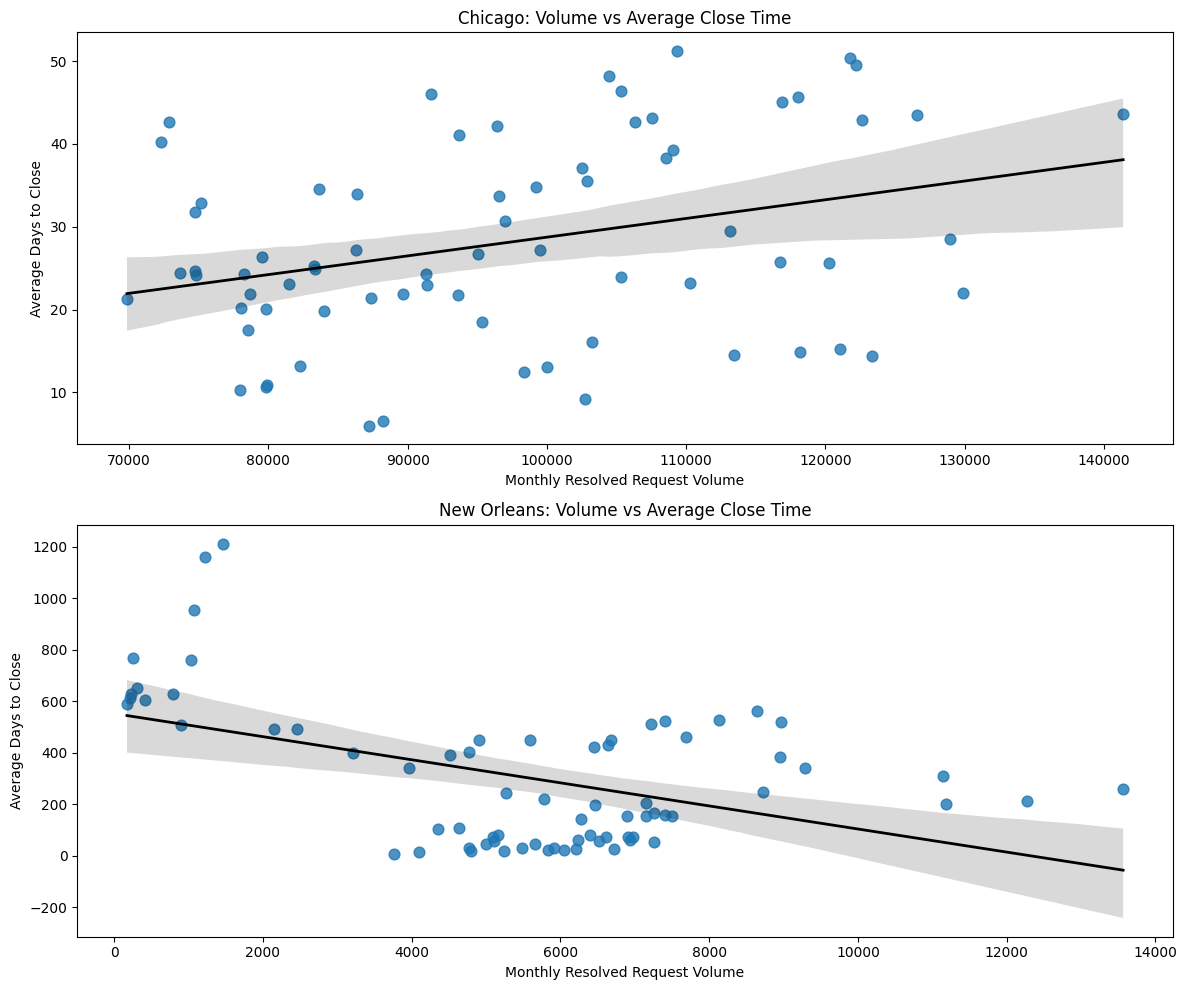

In [106]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from scipy.stats import pearsonr

### build a monthly combined panel from resolved requests only
nola_model_2 = nola_resolved.copy()
nola_model_2['city'] = 'New Orleans'
nola_model_2['year_month'] = nola_model_2['date_created'].dt.to_period('M').astype(str)

chi_model_2 = chi_resolved.copy()
chi_model_2['city'] = 'Chicago'
chi_model_2['year_month'] = chi_model_2['date_created'].dt.to_period('M').astype(str)

model_2_base = pd.concat(
    [
        nola_model_2[['city', 'year_month', 'time_to_close_days']],
        chi_model_2[['city', 'year_month', 'time_to_close_days']]
    ],
    ignore_index=True
)

model_2_monthly = (
    model_2_base
    .groupby(['city', 'year_month'], as_index=False)
    .agg(
        request_volume=('time_to_close_days', 'size'),
        avg_close_days=('time_to_close_days', 'mean'),
        median_close_days=('time_to_close_days', 'median')
    )
    .sort_values(['city', 'year_month'])
    .reset_index(drop=True)
)

model_2_results = []

for city_name, city_df in model_2_monthly.groupby('city'):
    avg_correlation, avg_p_value = pearsonr(city_df['request_volume'], city_df['avg_close_days'])

    model_2_results.append({
        'city': city_name,
        'months_used': len(city_df),
        'pearson_r': avg_correlation,
        'p_value': avg_p_value
    })

model_2_results = pd.DataFrame(model_2_results)
model_2_results[['pearson_r', 'p_value']] = model_2_results[['pearson_r', 'p_value']].round(4)

display(model_2_results)

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharey=False)
city_order = ['Chicago', 'New Orleans']

for ax, city_name in zip(axes, city_order):
    city_df = model_2_monthly[model_2_monthly['city'] == city_name]
    sns.regplot(
        data=city_df,
        x='request_volume',
        y='avg_close_days',
        ax=ax,
        scatter_kws={'s': 60},
        line_kws={'color': 'black', 'linewidth': 2}
    )
    ax.set_title(f'{city_name}: Volume vs Average Close Time')
    ax.set_xlabel('Monthly Resolved Request Volume')
    ax.set_ylabel('Average Days to Close')

plt.tight_layout()
plt.show()


### Hypothesis 2 Interpretation

The city-level Pearson results suggest different relationships between monthly request volume and average close time in the two cities. In Chicago, the correlation is positive (r = 0.3264, p = 0.0051), which means months with more resolved requests tend to also have longer average closure times. The relationship is statistically significant, but the effect size is modest.

In New Orleans, the correlation is negative (r = -0.4764, p < 0.0001), which means months with higher resolved request volume tend to have lower average close times. This relationship is also statistically significant and somewhat stronger in magnitude than the Chicago relationship.

Substantively, Hypothesis 2 receives mixed support rather than uniform support across both cities. Chicago fits the idea that heavier request volume is associated with slower average resolution, but New Orleans shows the opposite pattern. That suggests the volume-efficiency relationship is city-specific and may depend on different seasonal demand patterns, operational capacity, or the mix of request types being resolved each month.


### Predictive Modelling

Since there are peculiarities for the resolution time, top requests and peak drivers between the two cities, I am interested to see if I can create a resolution predictor model that works on both the cities or two models, one for each! The reason is while I have made my assessment, I am not sure if I am correct and whether there is actually a pattern for the resolution time and other factors discussed below. 

**Resolution Predictor**: The aim of this model is to determine how geographical location, time of the year, and request type impact the time it takes for a city to resolve a 311 request.

**Goal**: Predict the Resolution Time in days for a specific service request.

**Independent Variables**: General Request Category (e.g., sanitation, infrastructure), City (New Orleans vs. Chicago), District/Precinct, and Temporal factors.

**Dependent Variable**: Days to Close (calculated as Closed_Date - Created_Date).

**Methodology**: I will use a Random Forest Regressor to handle the categorical data and non-linear relationships. Evaluation will be based on Root Mean Squared Error (RMSE) and R-squared to measure how much variance in city efficiency is explained by these factors.

#### How these Models are Built

I had to limit the data used due to smaller New Orleans data size, in addition to New Orleans data having records with close date before the open date. 

I start with request reason, status, add a city column, create a shared geography field called geo_uni with district/precinct, and derive created_month, created_day_of_week, and created_hour from date_created. 

The combined-city version of Model 1 uses a reduced shared feature set so the model trains in a reasonable time (ran for over 12 hours and never stopped) while still keeping the main operational and timing predictors. 

In the combined-city models, the feature set used in the code is: request_reason, responsible_agency, city, geo_unit, created_month, created_day_of_week, and created_hour. The target is time_to_close_days. After combining both cities, I sample up to 390000 rows from each city, so the shared training dataset can contain as many as 780000 rows total while still staying balanced across Chicago and New Orleans.

The city-specific models use a richer local feature set. In both New Orleans and Chicago, the no-history and history versions use request_reason, responsible_agency, geo_unit, created_month, created_day_of_week, created_hour, created_quarter, latitude, and longitude. The historical versions then add one extra derived numeric feature: request_reason_historical_median_close_days, computed from the training split only. Each city-specific model samples up to 390000 resolved rows from that city.

Across these models, the data is split into training and test sets with a 10 percent holdout. The combined-city models stratify by city so both cities stay represented in the test set. Categorical fields are imputed and one-hot encoded, numeric fields are median-imputed, and the processed features are then passed into a RandomForestRegressor pipeline.


#### Reading The Random Forest Models

These random forest models are trying to predict time_to_close_days, which is the number of days between when a 311 request was created and when it was closed.

What a random forest is doing here
- A random forest builds many decision trees instead of one single tree.
- Each tree sees a slightly different sample of the training data and a slightly different subset of features.
- For regression, the final prediction is the average of all tree predictions.
- This usually performs better than one tree because it reduces overfitting and captures nonlinear patterns.

Why these models make sense for this project
- Closure time probably depends on combinations of factors rather than one linear rule.
- For example, a request may close differently depending on the request type, city, agency, location, and time of year.
- Random forests are useful here because they can model those interactions without requiring a strict linear relationship.

How to read the performance metrics
- RMSE: typical size of larger prediction errors, with extra penalty for very bad misses.
- MAE: average absolute prediction error in days.
- R-squared: proportion of variation in closure time explained by the model.

What the model comparison is testing
- Combined-city models ask whether one shared structure works across both cities.
- City-specific models ask whether performance improves when each city gets its own model.
- Historical-median versions test whether adding past category-level timing information improves prediction enough to justify the extra complexity.


#### Model 1.1: Combined-City Random Forest With Reduced Feature Set


#### Importing Libraries

In [73]:
import time
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


#### The model itself

In [81]:
### train and evaluate Model 1a: combined-city random forest with reduced feature set
feature_columns = [
    'request_reason', 'responsible_agency', 'city', 'geo_unit',
    'created_month', 'created_day_of_week', 'created_hour'
]
target_column = 'time_to_close_days'

X = combined_model_sample[feature_columns].copy()
y = combined_model_sample[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42,
    stratify=combined_model_sample['city']
)

print('Training rows:', len(X_train))
print('Test rows:', len(X_test))
print('Preparing to fit Model 1a...')

categorical_features = [
    'request_reason', 'responsible_agency', 'city', 'geo_unit',
    'created_month', 'created_day_of_week'
]
numeric_features = ['created_hour']

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_features
        ),
        (
            'numeric',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median'))
            ]),
            numeric_features
        )
    ]
)

model_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        verbose=1
    ))
])

fit_start = time.time()
print('Model 1a training started...')
model_1.fit(X_train, y_train)
print(f'Model 1a training finished in {(time.time() - fit_start) / 60:.2f} minutes')

predict_start = time.time()
print('Generating predictions on the test set...')
y_pred = model_1.predict(X_test)
print(f'Prediction step finished in {time.time() - predict_start:.2f} seconds')

overall_rmse = mean_squared_error(y_test, y_pred) ** 0.5

model_1_results = pd.DataFrame({
    'metric': ['RMSE', 'MAE', 'R-squared'],
    'value': [
        overall_rmse,
        mean_absolute_error(y_test, y_pred),
        r2_score(y_test, y_pred)
    ]
})

test_results = X_test.copy()
test_results['actual_days_to_close'] = y_test.values
test_results['predicted_days_to_close'] = y_pred

city_level_model_1_results = []
for city_name, city_df in test_results.groupby('city'):
    city_level_model_1_results.append({
        'city': city_name,
        'RMSE': mean_squared_error(city_df['actual_days_to_close'], city_df['predicted_days_to_close']) ** 0.5,
        'MAE': mean_absolute_error(city_df['actual_days_to_close'], city_df['predicted_days_to_close']),
        'R-squared': r2_score(city_df['actual_days_to_close'], city_df['predicted_days_to_close'])
    })

city_level_model_1_results = pd.DataFrame(city_level_model_1_results)

display(model_1_results)
display(city_level_model_1_results)

Training rows: 702000
Test rows: 78000
Preparing to fit Model 1a...
Model 1a training started...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 11 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-1)]: Done 178 tasks      | elapsed: 16.0min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed: 17.3min finished


Model 1a training finished in 17.30 minutes
Generating predictions on the test set...


[Parallel(n_jobs=11)]: Using backend ThreadingBackend with 11 concurrent workers.
[Parallel(n_jobs=11)]: Done  28 tasks      | elapsed:    0.2s
[Parallel(n_jobs=11)]: Done 178 tasks      | elapsed:    1.0s
[Parallel(n_jobs=11)]: Done 200 out of 200 | elapsed:    1.0s finished


Prediction step finished in 1.64 seconds


,metric,value
0,RMSE,225.006214
1,MAE,106.078961
2,R-squared,0.476745


,city,RMSE,MAE,R-squared
0,Chicago,73.879883,23.574331,0.469700
1,New Orleans,309.511478,188.583592,0.405108


#### Model 1.1 Interpretation

This combined-city random forest was trained on 702000 rows and evaluated on 78000 test rows. Its overall performance is moderate: RMSE is about 225.01 days, MAE is about 106.08 days, and R-squared is about 0.477. In practical terms, the model captures a meaningful share of the variation in closure time, but prediction errors are still fairly large in day units, which suggests that closure time remains a noisy outcome even after using request type, agency, city, geography, and timing features.

The city-level results show that the shared model fits Chicago better than New Orleans. For Chicago, RMSE is about 73.88 days, MAE is about 23.57 days, and R-squared is about 0.470. For New Orleans, RMSE is much higher at about 309.51 days, MAE is about 188.58 days, and R-squared is about 0.405. This suggests that the combined model generalizes reasonably across both cities, but New Orleans is harder to predict accurately, likely because its closure times are more variable or influenced by factors not fully captured in the reduced shared feature set.

Substantively, this means the reduced combined-city model is useful as a baseline and does detect real structure in the data, but it also leaves room for improvement. The weaker New Orleans fit is a good reason to compare this shared model against richer city-specific models in the next sections.

#### Model 1.2-1.5: Separate City Random Forests

The next four cells shift from one shared cross-city model to city-specific models. The purpose of this section is to test whether prediction improves once each city is allowed to use its own local structure instead of forcing Chicago and New Orleans into one combined model.

Each city gets two versions of the model. The first is a baseline model that uses the full local feature set without a historical median feature. The second keeps the same feature set but adds a historical request-type median so we can test whether past timing information improves prediction. In all four city-specific models, the data comes from resolved requests only, each city is sampled down to at most 390000 rows if needed, and 10 percent of the sampled data is held out for testing.


#### Model 1.2: New Orleans Random Forest Without Historical Median

This is the New Orleans model. It uses the full New Orleans feature set: request_reason, responsible_agency, geo_unit, created_month, created_day_of_week, created_hour, created_quarter, latitude, and longitude. The goal here is to see how well a city-specific model performs for New Orleans before adding any historical request-type timing information.


In [ ]:
import time

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

nola_model_rf_compare = nola_resolved.copy()
nola_model_rf_compare['geo_unit'] = nola_model_rf_compare['council_district'].astype('string')
nola_model_rf_compare['created_month'] = nola_model_rf_compare['date_created'].dt.month.astype('string')
nola_model_rf_compare['created_day_of_week'] = nola_model_rf_compare['date_created'].dt.day_name().astype('string')
nola_model_rf_compare['created_hour'] = nola_model_rf_compare['date_created'].dt.hour
nola_model_rf_compare['created_quarter'] = ('Q' + nola_model_rf_compare['date_created'].dt.quarter.astype(str)).astype('string')

nola_feature_columns_no_history = [
    'request_reason', 'responsible_agency', 'geo_unit',
    'created_month', 'created_day_of_week', 'created_hour',
    'created_quarter', 'latitude', 'longitude'
]
target_column = 'time_to_close_days'
sample_size = 390000

nola_model_rf_compare = nola_model_rf_compare[
    nola_feature_columns_no_history + [target_column]
].dropna(subset=[target_column]).copy()

nola_model_rf_compare['geo_unit'] = nola_model_rf_compare['geo_unit'].fillna('Missing')
nola_model_rf_compare['created_month'] = nola_model_rf_compare['created_month'].fillna('Missing')
nola_model_rf_compare['created_day_of_week'] = nola_model_rf_compare['created_day_of_week'].fillna('Missing')
nola_model_rf_compare['created_quarter'] = nola_model_rf_compare['created_quarter'].fillna('Missing')
nola_model_rf_compare['responsible_agency'] = nola_model_rf_compare['responsible_agency'].fillna('Missing')
nola_model_rf_compare['request_reason'] = nola_model_rf_compare['request_reason'].fillna('Missing')

nola_model_rf_compare = nola_model_rf_compare.sample(
    n=min(len(nola_model_rf_compare), sample_size),
    random_state=42
)

X = nola_model_rf_compare[nola_feature_columns_no_history]
y = nola_model_rf_compare[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42
)

categorical_features = [
    'request_reason', 'responsible_agency', 'geo_unit',
    'created_month', 'created_day_of_week', 'created_quarter'
]
numeric_features = ['created_hour', 'latitude', 'longitude']

nola_preprocessor_no_history = ColumnTransformer(
    transformers=[
        (
            'categorical',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_features
        ),
        (
            'numeric',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median'))
            ]),
            numeric_features
        )
    ]
)

nola_rf_model_no_history = Pipeline([
    ('preprocessor', nola_preprocessor_no_history),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        verbose=1
    ))
])

fit_start = time.time()
print('Training New Orleans random forest without historical feature...')
nola_rf_model_no_history.fit(X_train, y_train)
print(f'New Orleans no-history model training finished in {(time.time() - fit_start) / 60:.2f} minutes')

predict_start = time.time()
y_pred = nola_rf_model_no_history.predict(X_test)
print(f'Prediction step finished in {time.time() - predict_start:.2f} seconds')

nola_rf_no_history_results = pd.DataFrame([{
    'model': 'Without Historical Feature',
    'RMSE': mean_squared_error(y_test, y_pred) ** 0.5,
    'MAE': mean_absolute_error(y_test, y_pred),
    'R-squared': r2_score(y_test, y_pred)
}])

display(nola_rf_no_history_results)


Training New Orleans random forest without historical feature...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 11 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 178 tasks      | elapsed:  7.4min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  7.8min finished
[Parallel(n_jobs=11)]: Using backend ThreadingBackend with 11 concurrent workers.
[Parallel(n_jobs=11)]: Done  28 tasks      | elapsed:    0.1s


New Orleans no-history model training finished in 7.88 minutes
Prediction step finished in 0.55 seconds


[Parallel(n_jobs=11)]: Done 178 tasks      | elapsed:    0.4s
[Parallel(n_jobs=11)]: Done 200 out of 200 | elapsed:    0.5s finished


,model,RMSE,MAE,R-squared
0,Without Historical Feature,288.413762,173.639428,0.462558


#### Model 1.3: New Orleans Random Forest With Historical Request-Type Median

This second New Orleans model keeps the same full predictor set as the baseline model but adds one extra feature: the historical median close time for each request_reason. That historical value is computed from the training split only and then mapped into both the train and test data so the comparison stays leakage-safe. This model tests whether request-type history improves prediction for New Orleans.


In [99]:
import time

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

nola_model_rf_history = nola_resolved.copy()
nola_model_rf_history['geo_unit'] = nola_model_rf_history['council_district'].astype('string')
nola_model_rf_history['created_month'] = nola_model_rf_history['date_created'].dt.month.astype('string')
nola_model_rf_history['created_day_of_week'] = nola_model_rf_history['date_created'].dt.day_name().astype('string')
nola_model_rf_history['created_hour'] = nola_model_rf_history['date_created'].dt.hour
nola_model_rf_history['created_quarter'] = ('Q' + nola_model_rf_history['date_created'].dt.quarter.astype(str)).astype('string')

nola_feature_columns_history = [
    'request_reason', 'responsible_agency', 'geo_unit',
    'created_month', 'created_day_of_week', 'created_hour',
    'created_quarter', 'latitude', 'longitude'
]
target_column = 'time_to_close_days'
sample_size = 390000

nola_model_rf_history = nola_model_rf_history[
    nola_feature_columns_history + [target_column]
].dropna(subset=[target_column]).copy()

nola_model_rf_history['geo_unit'] = nola_model_rf_history['geo_unit'].fillna('Missing')
nola_model_rf_history['created_month'] = nola_model_rf_history['created_month'].fillna('Missing')
nola_model_rf_history['created_day_of_week'] = nola_model_rf_history['created_day_of_week'].fillna('Missing')
nola_model_rf_history['created_quarter'] = nola_model_rf_history['created_quarter'].fillna('Missing')
nola_model_rf_history['responsible_agency'] = nola_model_rf_history['responsible_agency'].fillna('Missing')
nola_model_rf_history['request_reason'] = nola_model_rf_history['request_reason'].fillna('Missing')

nola_model_rf_history = nola_model_rf_history.sample(
    n=min(len(nola_model_rf_history), sample_size),
    random_state=42
)

X = nola_model_rf_history[nola_feature_columns_history].copy()
y = nola_model_rf_history[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42
)

request_type_history = y_train.groupby(X_train['request_reason']).median()
overall_train_median = y_train.median()
X_train['request_reason_historical_median_close_days'] = (
    X_train['request_reason'].map(request_type_history).fillna(overall_train_median)
)
X_test['request_reason_historical_median_close_days'] = (
    X_test['request_reason'].map(request_type_history).fillna(overall_train_median)
)

categorical_features = [
    'request_reason', 'responsible_agency', 'geo_unit',
    'created_month', 'created_day_of_week', 'created_quarter'
]
numeric_features = ['created_hour', 'latitude', 'longitude', 'request_reason_historical_median_close_days']

nola_preprocessor_history = ColumnTransformer(
    transformers=[
        (
            'categorical',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_features
        ),
        (
            'numeric',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median'))
            ]),
            numeric_features
        )
    ]
)

nola_rf_model_history = Pipeline([
    ('preprocessor', nola_preprocessor_history),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        verbose=1
    ))
])

fit_start = time.time()
print('Training New Orleans random forest with historical feature...')
nola_rf_model_history.fit(X_train, y_train)
print(f'New Orleans history model training finished in {(time.time() - fit_start) / 60:.2f} minutes')

predict_start = time.time()
y_pred = nola_rf_model_history.predict(X_test)
print(f'Prediction step finished in {time.time() - predict_start:.2f} seconds')

nola_rf_history_results = pd.DataFrame([{
    'model': 'With Historical Request-Type Median',
    'RMSE': mean_squared_error(y_test, y_pred) ** 0.5,
    'MAE': mean_absolute_error(y_test, y_pred),
    'R-squared': r2_score(y_test, y_pred)
}])

display(nola_rf_history_results)

if 'nola_rf_no_history_results' in globals():
    nola_rf_comparison = pd.concat(
        [nola_rf_no_history_results, nola_rf_history_results],
        ignore_index=True
    )
    display(nola_rf_comparison)


Training New Orleans random forest with historical feature...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 11 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:   59.6s
[Parallel(n_jobs=-1)]: Done 178 tasks      | elapsed:  6.0min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed: 10.0min finished
[Parallel(n_jobs=11)]: Using backend ThreadingBackend with 11 concurrent workers.


New Orleans history model training finished in 9.98 minutes


[Parallel(n_jobs=11)]: Done  28 tasks      | elapsed:    0.1s
[Parallel(n_jobs=11)]: Done 178 tasks      | elapsed:    0.5s


Prediction step finished in 0.90 seconds


[Parallel(n_jobs=11)]: Done 300 out of 300 | elapsed:    0.8s finished


,model,RMSE,MAE,R-squared
0,With Historical Request-Type Median,287.967718,173.746596,0.464219


#### Model 1.2 and 1.3 Interpretation

For New Orleans, both city-specific models perform at a similar level, but the historical request-type median gives a very small improvement overall. The no-history model records RMSE of about 288.41 days, MAE of about 173.64 days, and R-squared of about 0.463. The history model improves RMSE slightly to about 287.97 days and raises R-squared slightly to about 0.464, although MAE increases a little to about 173.75 days.

This means the historical feature helps only marginally for New Orleans. It adds a small amount of useful information about typical closure time by request type, but it does not fundamentally change predictive performance. The practical takeaway is that most of the predictive signal is already being captured by the full baseline feature set, and request-type history only provides a minor refinement rather than a major improvement.

Substantively, the comparison suggests that New Orleans closure times are influenced by factors beyond request type history alone. Geography, timing, and agency matter, but there is still substantial unexplained variation, which is why prediction error remains fairly large even in the improved version.

#### Model 1.4: Chicago Random Forest Without Historical Feature

This is the Chicago baseline model. It uses the full Chicago feature set: request_reason, geo_unit, created_month, created_day_of_week, created_hour, responsible_agency, created_quarter, latitude, and longitude. The goal is to measure how well a city-specific Chicago model performs before any historical request-type timing feature is introduced.


In [ ]:
import time

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

chi_model_rf_compare = chi_resolved.copy()
chi_model_rf_compare['geo_unit'] = chi_model_rf_compare['precinct'].astype('string')
chi_model_rf_compare['created_month'] = chi_model_rf_compare['date_created'].dt.month.astype('string')
chi_model_rf_compare['created_day_of_week'] = chi_model_rf_compare['date_created'].dt.day_name().astype('string')
chi_model_rf_compare['created_hour'] = chi_model_rf_compare['date_created'].dt.hour
chi_model_rf_compare['created_quarter'] = ('Q' + chi_model_rf_compare['date_created'].dt.quarter.astype(str)).astype('string')

chi_feature_columns_no_history = [
    'request_reason', 'geo_unit', 'created_month',
    'created_day_of_week', 'created_hour', 'responsible_agency',
    'created_quarter', 'latitude', 'longitude'
]
target_column = 'time_to_close_days'
sample_size = 390000

chi_model_rf_compare = chi_model_rf_compare[
    chi_feature_columns_no_history + [target_column]
].dropna(subset=[target_column]).copy()

chi_model_rf_compare['geo_unit'] = chi_model_rf_compare['geo_unit'].fillna('Missing')
chi_model_rf_compare['created_month'] = chi_model_rf_compare['created_month'].fillna('Missing')
chi_model_rf_compare['created_day_of_week'] = chi_model_rf_compare['created_day_of_week'].fillna('Missing')
chi_model_rf_compare['created_quarter'] = chi_model_rf_compare['created_quarter'].fillna('Missing')
chi_model_rf_compare['responsible_agency'] = chi_model_rf_compare['responsible_agency'].fillna('Missing')
chi_model_rf_compare['request_reason'] = chi_model_rf_compare['request_reason'].fillna('Missing')

chi_model_rf_compare = chi_model_rf_compare.sample(
    n=min(len(chi_model_rf_compare), sample_size),
    random_state=42
)

X = chi_model_rf_compare[chi_feature_columns_no_history]
y = chi_model_rf_compare[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42
)

categorical_features = [
    'request_reason', 'geo_unit', 'responsible_agency',
    'created_month', 'created_day_of_week', 'created_quarter'
]
numeric_features = ['created_hour', 'latitude', 'longitude']

chi_preprocessor_no_history = ColumnTransformer(
    transformers=[
        (
            'categorical',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_features
        ),
        (
            'numeric',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median'))
            ]),
            numeric_features
        )
    ]
)

chicago_rf_model_no_history = Pipeline([
    ('preprocessor', chi_preprocessor_no_history),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        verbose=1
    ))
])

fit_start = time.time()
print('Training Chicago random forest without historical feature...')
chicago_rf_model_no_history.fit(X_train, y_train)
print(f'Chicago no-history model training finished in {(time.time() - fit_start) / 60:.2f} minutes')

predict_start = time.time()
y_pred = chicago_rf_model_no_history.predict(X_test)
print(f'Prediction step finished in {time.time() - predict_start:.2f} seconds')

chicago_rf_no_history_results = pd.DataFrame([{
    'model': 'Without Historical Feature',
    'RMSE': mean_squared_error(y_test, y_pred) ** 0.5,
    'MAE': mean_absolute_error(y_test, y_pred),
    'R-squared': r2_score(y_test, y_pred)
}])

display(chicago_rf_no_history_results)


Training Chicago random forest without historical feature...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 11 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 178 tasks      | elapsed:  8.4min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  9.0min finished


Chicago no-history model training finished in 9.05 minutes


[Parallel(n_jobs=11)]: Using backend ThreadingBackend with 11 concurrent workers.
[Parallel(n_jobs=11)]: Done  28 tasks      | elapsed:    0.1s


Prediction step finished in 0.77 seconds


[Parallel(n_jobs=11)]: Done 178 tasks      | elapsed:    0.3s
[Parallel(n_jobs=11)]: Done 200 out of 200 | elapsed:    0.3s finished


,model,RMSE,MAE,R-squared
0,Without Historical Feature,67.998303,22.20064,0.521036


#### Model 1.5: Chicago Random Forest With Historical Request-Type Median

This second Chicago model keeps the same full Chicago predictor set as the baseline version and adds the historical median close time for each request_reason. As in the New Orleans history model, that feature is computed from the training split only and then mapped into the train and test rows. This lets the comparison focus on whether historical request-type timing improves prediction for Chicago.


In [ ]:
import time

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

chi_model_rf_history = chi_resolved.copy()
chi_model_rf_history['geo_unit'] = chi_model_rf_history['precinct'].astype('string')
chi_model_rf_history['created_month'] = chi_model_rf_history['date_created'].dt.month.astype('string')
chi_model_rf_history['created_day_of_week'] = chi_model_rf_history['date_created'].dt.day_name().astype('string')
chi_model_rf_history['created_hour'] = chi_model_rf_history['date_created'].dt.hour
chi_model_rf_history['created_quarter'] = ('Q' + chi_model_rf_history['date_created'].dt.quarter.astype(str)).astype('string')

chi_feature_columns_history = [
    'request_reason', 'geo_unit', 'created_month',
    'created_day_of_week', 'created_hour', 'responsible_agency',
    'created_quarter', 'latitude', 'longitude'
]
target_column = 'time_to_close_days'
sample_size = 390000

chi_model_rf_history = chi_model_rf_history[
    chi_feature_columns_history + [target_column]
].dropna(subset=[target_column]).copy()

chi_model_rf_history['geo_unit'] = chi_model_rf_history['geo_unit'].fillna('Missing')
chi_model_rf_history['created_month'] = chi_model_rf_history['created_month'].fillna('Missing')
chi_model_rf_history['created_day_of_week'] = chi_model_rf_history['created_day_of_week'].fillna('Missing')
chi_model_rf_history['created_quarter'] = chi_model_rf_history['created_quarter'].fillna('Missing')
chi_model_rf_history['responsible_agency'] = chi_model_rf_history['responsible_agency'].fillna('Missing')
chi_model_rf_history['request_reason'] = chi_model_rf_history['request_reason'].fillna('Missing')

chi_model_rf_history = chi_model_rf_history.sample(
    n=min(len(chi_model_rf_history), sample_size),
    random_state=42
)

X = chi_model_rf_history[chi_feature_columns_history].copy()
y = chi_model_rf_history[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42
)

request_type_history = y_train.groupby(X_train['request_reason']).median()
overall_train_median = y_train.median()
X_train['request_reason_historical_median_close_days'] = (
    X_train['request_reason'].map(request_type_history).fillna(overall_train_median)
)
X_test['request_reason_historical_median_close_days'] = (
    X_test['request_reason'].map(request_type_history).fillna(overall_train_median)
)

categorical_features = [
    'request_reason', 'geo_unit', 'responsible_agency',
    'created_month', 'created_day_of_week', 'created_quarter'
]
numeric_features = ['created_hour', 'latitude', 'longitude', 'request_reason_historical_median_close_days']

chi_preprocessor_history = ColumnTransformer(
    transformers=[
        (
            'categorical',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_features
        ),
        (
            'numeric',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median'))
            ]),
            numeric_features
        )
    ]
)

chicago_rf_model_history = Pipeline([
    ('preprocessor', chi_preprocessor_history),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        verbose=1
    ))
])

fit_start = time.time()
print('Training Chicago random forest with historical feature...')
chicago_rf_model_history.fit(X_train, y_train)
print(f'Chicago history model training finished in {(time.time() - fit_start) / 60:.2f} minutes')

predict_start = time.time()
y_pred = chicago_rf_model_history.predict(X_test)
print(f'Prediction step finished in {time.time() - predict_start:.2f} seconds')

chicago_rf_history_results = pd.DataFrame([{
    'model': 'With Historical Request-Type Median',
    'RMSE': mean_squared_error(y_test, y_pred) ** 0.5,
    'MAE': mean_absolute_error(y_test, y_pred),
    'R-squared': r2_score(y_test, y_pred)
}])

display(chicago_rf_history_results)

if 'chicago_rf_no_history_results' in globals():
    chicago_rf_comparison = pd.concat(
        [chicago_rf_no_history_results, chicago_rf_history_results],
        ignore_index=True
    )
    display(chicago_rf_comparison)


Training Chicago random forest with historical feature...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 11 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 178 tasks      | elapsed:  8.5min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  9.3min finished


Chicago history model training finished in 9.28 minutes


[Parallel(n_jobs=11)]: Using backend ThreadingBackend with 11 concurrent workers.
[Parallel(n_jobs=11)]: Done  28 tasks      | elapsed:    0.1s


Prediction step finished in 0.80 seconds


[Parallel(n_jobs=11)]: Done 178 tasks      | elapsed:    0.3s
[Parallel(n_jobs=11)]: Done 200 out of 200 | elapsed:    0.3s finished


,model,RMSE,MAE,R-squared
0,With Historical Request-Type Median,67.925461,22.193449,0.522061


,model,RMSE,MAE,R-squared
0,Without Historical Feature,67.998303,22.200640,0.521036
1,With Historical Request-Type Median,67.925461,22.193449,0.522061


: 

#### Model 1.4 and 1.5 Interpretation

For Chicago, both city-specific models perform strongly and very similarly, but the historical request-type median gives a small improvement across all three metrics. The no-history model records RMSE of about 68.00 days, MAE of about 22.20 days, and R-squared of about 0.521. The history model improves RMSE slightly to about 67.93 days, lowers MAE slightly to about 22.19 days, and raises R-squared slightly to about 0.522.

This means the historical feature helps, but only marginally. Chicago already appears easier to predict than New Orleans using the full city-specific feature set, and most of the predictive signal is already being captured by request type, geography, timing, agency, and location. The historical median adds a bit of extra structure, but it does not create a dramatic jump in performance.

Substantively, the Chicago results suggest that closure times are more predictable and more consistently patterned than in New Orleans. Even so, the modest improvement from the historical feature shows that request-type history is useful mainly as a refinement rather than a major new source of predictive power.

## Conclusion 

This project was motivated by a simple question: how do two different cities respond to resident service requests, and can those differences be explained statistically and modeled predictively? By comparing Chicago and New Orleans 311 data, I wanted to understand not just what people report, but when they report it, how quickly cities respond, and whether geography, seasonality, and request type create meaningful differences in civic responsiveness.

- The inquiry showed that the two cities differ in both request composition and service dynamics.
- Chicago generated far more requests overall, even after accounting for population differences, and it showed stronger seasonal swings in request type than New Orleans.
- The hypothesis testing supported that pattern: request composition changes significantly across the year in both cities, but the effect is stronger in Chicago.
- The volume-efficiency test produced mixed results, with Chicago showing a positive relationship between monthly request volume and average close time, while New Orleans showed a negative relationship.
- This suggests that system strain does not affect both cities in the same way and that local context matters.

- The predictive modeling results showed that closure time is partly predictable, but not perfectly so.
- The combined-city random forest captured a meaningful share of the variation in days to close, though its errors remained fairly large, especially for New Orleans.
- City-specific models performed better than the shared baseline for understanding local structure, and the historical request-type median helped only slightly in both cities.
- Overall, the project suggests that 311 responsiveness is shaped by real and detectable patterns in request type, timing, agency, and geography, but it is also influenced by additional operational or contextual factors that are not fully captured in the available data.
